# Notebook 01 — EDA & Feature Engineering

**Module:** ITI113 Machine Learning & Operations  
**Focus Area:** A — Data & EDA  
**Project:** *Fair Advertised Nightly Rate* — regression on the 10-city Airbnb listings snapshot (early 2021)  


---

## What this notebook does

1. Loads `Listings.csv` (≈280k listings, 10 cities) and validates the schema, then uploads the raw file to S3
2. Assesses data suitability for modelling the binary target — whether an Airbnb listing is instant_bookable
3. Extensive EDA — the class distribution of instant_bookable, missingness patterns, host responsiveness & trust characteristics (host_response_time, host_response_rate, host_acceptance_rate, host_is_superhost), property/stay features, review score correlations, and pricing dynamics relative to instant-booking enablement
4. **Governance-driven cleaning** — — PII minimisation (listing_id, name, host_id), location privacy protection (latitude, longitude), duplicate removal, consistent handling of missing values (e.g., unrated listings, unrecorded response rates), documented outlier treatment (price, minimum_nights), target-label validation, and leakage prevention, with all cleaning decisions explicitly justified and reproducible.
5. **Feature engineering** — spatial coarsening, amenity parsing (detecting automation/friction-reducing perks), host trust/responsiveness composite indicators, capacity-to-room ratios, and stay-length constraints, each with a written logical, ethical, and mathematical rationale
6. Train/test split (80/20, stratified by city and target class instant_bookable) followed by all train-fitted transforms (imputation values, amenity vocabulary, caps, encodings, scaler)
7. Saves four processed CSVs **plus a preprocessing-artifacts JSON** to S3 for Notebook 02 and the pipeline

## Problem framing (read this first)

- **Task:** binary classification. The target is the discrete flag instant_bookable (1 = instant booking enabled, 0 = host manual approval required). Every EDA view, cleaning rule, feature, and (later) evaluation metric in this project is chosen for a binary classification target — focusing on log loss, ROC-AUC, PR-AUC, and probability calibration rather than continuous error metrics.
- **What a prediction means:** instant_bookable represents whether a guest can reserve a listing immediately without waiting up to 24 hours for host approval. We model the output as a calibrated "instant-booking propensity score" which reflects the likelihood or operational readiness of a listing to support instant reservations given its host, property, and pricing characteristics. In the downstream recommendation system, this score serves as a friction-reduction feature, combined with your teammate’s predicted continuous "fair advertised rate" to rank and filter search results according to guest booking intent.
- **Temporal scope:** the snapshot dates to early 2021 (COVID-suppressed travel). This notebook is a methodology demonstration: the pipeline is written so that re-pointing DATA_PATH at a fresh extract and re-running reproduces every artifact. Instant-booking adoption rates and host operational profiles learned from 2021 data must be re-calibrated before deployment in real-time recommendation engines under current market dynamics.

## Known data limitations and how this notebook handles them

| # | Limitation | Handling strategy (section) |
|---|------------|------------------------------|
| 1 | Target flag reflects host enablement, not guest demand | Frame target as instant-booking propensity / operational readiness; model outputs a calibrated probability, instant bookable =1 never to be narrated as booking volume or conversion rate|
| 2 | price feature is recorded in local currencies (THB vs EUR vs USD…) | As a predictor, raw price cannot be pooled across cities. Model log1p(price) with city one-hot encoding and within-city price scaling so currency base differences do not distort classification weights |
| 3 | Snapshot is stale (early 2021) | Host instant-booking policies were heavily influenced by COVID-era travel rules. Retain methodology-demo framing; construct a deterministic, re-runnable pipeline with snapshot date pinned in config|
| 4 | Missing self-reported fields (response rates ≈46%, review scores ≈33%) | Missingness in host responsiveness and review scores carries signal about host activity level. Use missingness indicator flags + train-fitted imputation, never silent row drops |
| 5 | Free-text amenities field| Parse JSON list → canonicalise self-check-in and automation signals (e.g., Keypad, Smart lock, Self check-in) → fit top-K binary flags on train, roll rare amenities into a total count |
| 6 | Class imbalance across geographic sub-markets| Stratify train/test split jointly by city and target class (instant_bookable); evaluate using PR-AUC, ROC-AUC, Brier score, and log-loss rather than raw accuracy |

## How to adapt this for your own project

- Point `DATA_PATH` at your own extract (same schema) — every downstream constant lives in the config cell
- Adjust the policy constants (`TOP_K_AMENITIES`, `PRICE_CAP_QUANTILE`, `COORD_DECIMALS`, caps) in one place
- The S3 save logic at the end requires no changes

## Prerequisites

- SageMaker Studio, kernel **Python 3 (Data Science 3.0)**, instance `ml.t3.medium` — *the notebook also runs locally; S3 steps degrade gracefully*
- `Listings.csv` uploaded next to this notebook (or under `./data/`)
- SageMaker execution role has S3 read/write on the default bucket

In [1]:
import os, io, re, json, warnings
import numpy as np
import pandas as pd
import boto3

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# ---- Set environment explicitly to S3 / AWS Mode ----
LOCAL_MODE = False

# Initialize AWS Session & S3 Client
boto_session = boto3.Session()
region = boto_session.region_name or 'us-east-1'
s3 = boto_session.client('s3')

# Try loading SageMaker Session & Execution Role (fallback gracefully if using external IAM user/keys)
try:
    import sagemaker
    session = sagemaker.Session(boto_session=boto_session)
    role = sagemaker.get_execution_role()
except Exception:
    session = None
    role = "arn:aws:iam::default:role/LocalOrExternalRole"

TEAM_ID    = "team14"   # "team01"
STUDENT_ID = "s1401"    # "s004"

BUCKET = "nyp-26s1-iti113"
# Separate output prefix for instant-booking classification
PREFIX = f"iti113/{TEAM_ID}/data/airbnb-instant-booking"
LOCAL_OUT = "processed_instant_booking"

# ---- data source ----
DATA_CANDIDATES = [
    "Listings.csv", 
    os.path.join("data", "Listings.csv"),
    "/mnt/user-data/uploads/Listings.csv"
]
DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), DATA_CANDIDATES[0])

# ---- modelling constants (Binary Classification) ----
TARGET_COLUMN         = "instant_bookable"   # Binary target flag: 't'/'f' or 1/0
TARGET_POSITIVE_CLASS = 1                    # 1 = Instant booking enabled, 0 = Requires approval
RANDOM_STATE          = 42
TEST_SIZE             = 0.20
SNAPSHOT_DATE         = pd.Timestamp("2021-03-01")   # Data as-of date (max host_since = 2021-02-26)

# ---- classification & evaluation policy ----
DECISION_THRESHOLD    = 0.50                 # Default baseline; tune post-calibration
CALIBRATION_METHOD    = "isotonic"           # Ensures output probabilities are reliable for rankers
STRATIFY_COLUMNS      = ["city", "instant_bookable"]  # Joint stratification for regional/class balance

# ---- documented policy constants (outlier & feature engineering policies) ----
TOP_K_AMENITIES       = 30      # Amenity vocabulary size (capturing self-checkin/keypads), fit on train
COORD_DECIMALS        = 2       # Coordinate rounding: 2 dp ~ 1.1 km cells (geo-privacy)
PRICE_CAP_QUANTILE    = 0.995   # Feature-level price winsorisation per city, fit on train
COUNT_CAP_QUANTILE    = 0.99    # host_total_listings_count cap, fit on train
MIN_NIGHTS_CAP        = 365     # Domain constant: >1 year minimum stay is not nightly rental
MAX_NIGHTS_CAP        = 1125    # Platform default ceiling; larger values are sentinels
BEDROOMS_CAP          = 16      # Platform max party size; larger values are stability caps
SPARSITY_THRESHOLD    = 0.80    # Columns with >80% missing are dropped as unusable

# ---- fixed external reference points (NOT computed from data) ----
CITY_CENTERS = {                     # (lat, lon) of a canonical central landmark
    "Paris":          (48.8530,   2.3499),   # Notre-Dame
    "New York":       (40.7580, -73.9855),   # Times Square / Midtown
    "Sydney":         (-33.8568, 151.2153),  # Circular Quay
    "Rome":           (41.8986,  12.4769),   # Pantheon
    "Rio de Janeiro": (-22.9711, -43.1822),  # Copacabana
    "Istanbul":       (41.0054,  28.9768),   # Sultanahmet
    "Mexico City":    (19.4326, -99.1332),   # Zocalo
    "Bangkok":        (13.7460, 100.5340),   # Siam
    "Cape Town":      (-33.9221, 18.4231),   # City Centre
    "Hong Kong":      (22.2819, 114.1582),   # Central
}

# ---- verification output ----
print(f"Mode         : {'LOCAL (no SageMaker/S3)' if LOCAL_MODE else 'SageMaker / S3 Active'}")
print(f"Bucket       : {BUCKET}")
print(f"Prefix       : {PREFIX}")
print(f"Region       : {region}")
print(f"Role         : {role.split('/')[-1] if role else 'None'}")
print(f"Team ID      : {TEAM_ID}")
print(f"Student ID   : {STUDENT_ID}")
print(f"Task         : Binary Classification")
print(f"Target       : {TARGET_COLUMN}")
print(f"Data path    : {DATA_PATH}")
print(f"Snapshot     : {SNAPSHOT_DATE.date()}")
print(f"numpy {np.__version__} | pandas {pd.__version__}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Mode         : SageMaker / S3 Active
Bucket       : nyp-26s1-iti113
Prefix       : iti113/team14/data/airbnb-instant-booking
Region       : ap-southeast-1
Role         : SageMakerExecutionRole-ITI113-Team14
Team ID      : team14
Student ID   : s1401
Task         : Binary Classification
Target       : instant_bookable
Data path    : Listings.csv
Snapshot     : 2021-03-01
numpy 1.26.4 | pandas 2.3.3


## 1. Load Dataset & Schema Validation

The dataset is the 10-city Airbnb listings snapshot (`Listings.csv`, ≈280k rows × 33 columns): Paris, New York, Sydney, Rome, Rio de Janeiro, Istanbul, Mexico City, Bangkok, Cape Town and Hong Kong.

**Schema validation is the first quality gate**, not an afterthought: every column we rely on downstream is checked for 
(a) presence, 
(b) a coercible dtype family, and 
(c) basic domain (e.g. latitude within ±90). Failing loudly here is how a scheduled retraining pipeline detects an upstream extract change *before* it silently corrupts features. Note the file ships with some double-encoded UTF-8 in free-text fields (e.g. `Â²` artifacts in `name`) — we read defensively with `encoding_errors='replace'`; the affected fields are either repaired (`amenities`) or dropped for privacy (`name`).
(d) Target label validity: Explicitly verifying that instant_bookable contains only valid boolean/binary representations ('t', 'f', True, False, 1, 0) with zero unresolvable nulls.

| Column group | Columns |
|---|---|
| Identifiers | `listing_id`, `host_id` |
| Host profile (self-reported / platform) | `host_since`, `host_location`, `host_response_time`, `host_response_rate`, `host_acceptance_rate`, `host_is_superhost`, `host_total_listings_count`, `host_has_profile_pic`, `host_identity_verified` |
| Location | `neighbourhood`, `district`, `city`, `latitude`, `longitude` |
| Property | `property_type`, `room_type`, `accommodates`, `bedrooms`, `amenities` |
| Commercial terms | `price` , `minimum_nights`, `maximum_nights`, **`instant_bookable`(target)** |
| Guest feedback | `review_scores_rating` + six sub-scores |

In [2]:
# 1.0 Ingestion & Health Inspection
# ==============================================================================
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8', encoding_errors='replace', low_memory=False)
print(f"Shape          : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory         : {df_raw.memory_usage(deep=True).sum()/1e6:,.0f} MB")
print(f"Target present : {'instant_bookable' in df_raw.columns} | dtype={df_raw['instant_bookable'].dtype}")
df_raw.head(3)

Shape          : 279,712 rows x 33 columns


Memory         : 351 MB
Target present : True | dtype=object


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Buttes-Montmartre,NaN,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÂ² Paris (Sacre CÅ“ur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,t,Buttes-Montmartre,NaN,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,t,f,Elysee,NaN,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [3]:
# --- 1.1 Schema contract: presence + dtype family + hard domain checks -------
SCHEMA = {  # column -> expected dtype family
    'listing_id':'int','name':'str','host_id':'int','host_since':'date',
    'host_location':'str','host_response_time':'str','host_response_rate':'float',
    'host_acceptance_rate':'float','host_is_superhost':'tf','host_total_listings_count':'float',
    'host_has_profile_pic':'tf','host_identity_verified':'tf','neighbourhood':'str',
    'district':'str','city':'str','latitude':'float','longitude':'float',
    'property_type':'str','room_type':'str','accommodates':'int','bedrooms':'float',
    'amenities':'str','price':'int','minimum_nights':'int','maximum_nights':'int',
    'review_scores_rating':'float','review_scores_accuracy':'float',
    'review_scores_cleanliness':'float','review_scores_checkin':'float',
    'review_scores_communication':'float','review_scores_location':'float',
    'review_scores_value':'float','instant_bookable':'tf',
}
problems = []
missing_cols = set(SCHEMA) - set(df_raw.columns)
extra_cols   = set(df_raw.columns) - set(SCHEMA)
if missing_cols: problems.append(f"missing columns: {sorted(missing_cols)}")
if extra_cols:   problems.append(f"unexpected columns: {sorted(extra_cols)}")

for col, kind in SCHEMA.items():
    if col not in df_raw.columns:
        continue
    s = df_raw[col]
    if kind in ('int', 'float'):
        coerced = pd.to_numeric(s, errors='coerce')
        bad = coerced.isna() & s.notna()
        if bad.any(): problems.append(f"{col}: {bad.sum()} non-numeric values")
    elif kind == 'date':
        coerced = pd.to_datetime(s, errors='coerce')
        bad = coerced.isna() & s.notna()
        if bad.any(): problems.append(f"{col}: {bad.sum()} unparseable dates")
    elif kind == 'tf':
        bad = ~s.dropna().isin(['t', 'f'])
        if bad.any(): problems.append(f"{col}: {bad.sum()} values outside {{t,f}}")

# hard domain checks
if not df_raw['latitude'].between(-90, 90).all():   problems.append('latitude out of [-90,90]')
if not df_raw['longitude'].between(-180, 180).all(): problems.append('longitude out of [-180,180]')
if (pd.to_numeric(df_raw['price'], errors='coerce') < 0).any(): problems.append('negative prices found')
if set(df_raw['city'].unique()) - set(CITY_CENTERS): problems.append('city outside expected 10-city set')

if problems:
    raise ValueError('SCHEMA VALIDATION FAILED:\n  - ' + '\n  - '.join(problems))
print('SCHEMA VALIDATION PASSED')
print(f"  {len(SCHEMA)} columns present, dtype families coercible, coordinates and city set in-domain.")
print(f"  Cities: {df_raw['city'].nunique()} | Listings per city:")
print(df_raw['city'].value_counts().to_string())

SCHEMA VALIDATION PASSED
  33 columns present, dtype families coercible, coordinates and city set in-domain.


  Cities: 10 | Listings per city:
city
Paris             64690
New York          37012
Sydney            33630
Rome              27647
Rio de Janeiro    26615
Istanbul          24519
Mexico City       20065
Bangkok           19361
Cape Town         19086
Hong Kong          7087


In [4]:
# --- 1.2 Version-control the raw file in S3 (skipped gracefully in local mode)
if not LOCAL_MODE:
    RAW_S3_URI = f's3://{BUCKET}/{PREFIX}/raw/Listings.csv'
    s3.upload_file(DATA_PATH, BUCKET, f'{PREFIX}/raw/Listings.csv')
    print(f'Raw data uploaded to: {RAW_S3_URI}')
else:
    print('LOCAL_MODE: skipping raw S3 upload (would go to '
          f's3://{BUCKET}/{PREFIX}/raw/Listings.csv)')

Raw data uploaded to: s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/raw/Listings.csv


## 2. Data Suitability Assessment

Before investing in EDA and feature engineering, we verify the dataset can actually support a binary classification / logistic regression model of instant-booking enablement (instant_bookable). Four criteria:

1. **Target quality** — instant_bookable must be cleanly coercible to a binary flag (y= 0 or1),with non-trivial variation across classes within every city.Ensuring sufficient positive and negative support to learn stable decision boundaries and calibrated probability estimates.
2. **Sample size** — enough rows overall *and per city* to estimate city-level effects (the smallest market, Hong Kong, still has ≈7k listings — contains hundreds of instant-bookable instances — well above the minimum required for regularized logistic regression).
3. **Predictor coverage** — the operational drivers an operations or marketplace analyst would expect (host responsiveness and acceptance rates, superhost status, property size, check-in automation amenities like keypads/smart locks, stay constraints, and asking price) must all exist in the schema.
4. **Honest caveats** —  the ways this data can mislead (host enablement $\neq$ realized guest demand, local currency confounding in the price predictor, COVID-era snapshot staleness, and non-random missingness in self-reported host metrics) must have explicit, reproducible mitigations rather than unvalidated assumptions.

In [5]:
# STEP 2: DATA SUITABILITY ASSESSMENT (BINARY CLASSIFICATION)
# ==============================================================================

suit = df_raw.copy()

# 1. Map target to numeric binary format {0, 1}
suit['target_binary'] = suit['instant_bookable'].map({'t': 1, 'f': 0})
target_valid_mask = suit['target_binary'].notna()
target_null_count = suit['instant_bookable'].isna().sum()

rows = []

# --- 2.1 Target coverage ---
target_coverage_rate = suit['instant_bookable'].notna().mean() * 100
coverage_verdict = 'PASS' if target_null_count == 0 else 'PASS (with cleaning)'
rows.append((
    'Target coverage',
    f"{target_coverage_rate:.2f}% non-null ({target_null_count:,} null rows)",
    coverage_verdict
))

# --- 2.2 Target validity ---
all_valid_tokens = suit['instant_bookable'].dropna().isin(['t', 'f']).all()
validity_verdict = 'PASS' if all_valid_tokens else 'FAIL'
rows.append((
    'Target validity',
    f"{(target_valid_mask.mean() * 100):.2f}% cleanly maps to {{0, 1}} binary tokens",
    validity_verdict
))

# --- 2.3 Target class balance (Overall & Per-City) ---
pos_rate_overall = suit['target_binary'].mean() * 100
city_pos_rates = suit.groupby('city')['target_binary'].mean() * 100
min_city, max_city = city_pos_rates.idxmin(), city_pos_rates.idxmax()

# Rule: No severe class collapse (<1% or >99%) overall or in any individual market
is_balanced = (
    (1.0 <= pos_rate_overall <= 99.0) and
    (city_pos_rates.min() >= 1.0) and
    (city_pos_rates.max() <= 99.0)
)
balance_verdict = 'PASS' if is_balanced else 'FAIL'
rows.append((
    'Target class balance',
    f"Overall positive rate: {pos_rate_overall:.1f}% | Per-city range: {city_pos_rates.min():.1f}% ({min_city}) to {city_pos_rates.max():.1f}% ({max_city})",
    balance_verdict
))

# --- 2.4 Sample size & minority class support ---
min_city_count = suit['city'].value_counts().min()
min_city_name = suit['city'].value_counts().idxmin()
min_pos_support = suit[suit['target_binary'] == 1].groupby('city').size().min()

# Rule: Minimum 1,000 listings and at least 100 positive instances per city for stable fitting
has_sufficient_support = (min_city_count >= 1000) and (min_pos_support >= 100)
support_verdict = 'PASS' if has_sufficient_support else 'FAIL'
rows.append((
    'Sample size & minority support',
    f"{len(suit):,} total listings; smallest city = {min_city_count:,} ({min_city_name}) with {min_pos_support:,} positive cases",
    support_verdict
))

# --- 2.5 Feature & Driver availability checks ---
have = lambda cols: all(c in suit.columns for c in cols)

rows.append((
    'Host operational signals',
    'host_since, host_is_superhost, response_rate, acceptance_rate, listing_count',
    'PASS' if have(['host_since', 'host_is_superhost', 'host_response_rate', 'host_acceptance_rate', 'host_total_listings_count']) else 'FAIL'
))

rows.append((
    'Property & capacity drivers',
    'accommodates, bedrooms, room_type, property_type',
    'PASS' if have(['accommodates', 'bedrooms', 'room_type', 'property_type']) else 'FAIL'
))

rows.append((
    'Commercial terms (predictors)',
    'price (raw currency), minimum_nights, maximum_nights',
    'PASS' if have(['price', 'minimum_nights', 'maximum_nights']) else 'FAIL'
))

rows.append((
    'Automation & amenity signals',
    'amenities free-text (self check-in, keypads, smart locks)',
    'PASS' if 'amenities' in suit.columns else 'FAIL'
))

rows.append((
    'Location drivers',
    'latitude, longitude, neighbourhood, district, city',
    'PASS' if have(['latitude', 'longitude', 'neighbourhood', 'district', 'city']) else 'FAIL'
))

# --- 2.6 Missingness & Informative Signal Checks ---
rev_missing = suit['review_scores_rating'].isna().mean() * 100
rows.append((
    'Review signals',
    f"7 review sub-scores; {rev_missing:.0f}% missing -> indicator flags + train-fitted imputation (Step 6.2)",
    'PASS (with handling)' if 'review_scores_rating' in suit.columns else 'FAIL'
))

resp_missing = suit['host_response_rate'].isna().mean() * 100
acc_missing = suit['host_acceptance_rate'].isna().mean() * 100
rows.append((
    'Self-reported host fields',
    f"response rate {resp_missing:.0f}% / acceptance rate {acc_missing:.0f}% missing -> indicator flags + imputation",
    'PASS (with handling)' if have(['host_response_rate', 'host_acceptance_rate']) else 'FAIL'
))

# 3. Construct scorecard DataFrame
df_suitability = pd.DataFrame(rows, columns=['Criterion', 'Evidence', 'Verdict'])
display(df_suitability)

# Hard failure gate if any non-handling PASS criterion failed
critical_failures = df_suitability[df_suitability['Verdict'] == 'FAIL']
if not critical_failures.empty:
    raise ValueError(f"SUITABILITY CHECK FAILED:\n{critical_failures.to_string(index=False)}")

,Criterion,Evidence,Verdict
0,Target coverage,100.00% non-null (0 null rows),PASS
1,Target validity,"100.00% cleanly maps to {0, 1} binary tokens",PASS
2,Target class balance,Overall positive rate: 41.3% | Per-city range:...,PASS
3,Sample size & minority support,"279,712 total listings; smallest city = 7,087 ...",PASS
4,Host operational signals,"host_since, host_is_superhost, response_rate, ...",PASS
5,Property & capacity drivers,"accommodates, bedrooms, room_type, property_type",PASS
6,Commercial terms (predictors),"price (raw currency), minimum_nights, maximum_...",PASS
7,Automation & amenity signals,"amenities free-text (self check-in, keypads, s...",PASS
8,Location drivers,"latitude, longitude, neighbourhood, district, ...",PASS
9,Review signals,7 review sub-scores; 33% missing -> indicator ...,PASS (with handling)


## Verdict — suitable, with governed handling.
The dataset exhibits a fully populated, valid binary target (instant_bookable at 100% coverage) with a well-balanced overall positive rate (41.3%) and substantial sample support across all 10 international markets. It captures the full spectrum of operational, host behavioural, property, and friction-reducing amenity drivers required for classification.

The three structural technical challenges — 
1. currency-confounded price predictors,
2. substantial self-report missingness (40–46% in host responsiveness, 33% in review sub-scores), and
3. unparsed free-text amenities — are all tractable via the systematic strategies committed to in the limitations table

The two interpretive weaknesses cannot be engineered away and are strictly governed by narration:

1. Predictions represent instant-booking propensity / operational readiness, not realized booking transactions or guest demand volume — the dataset records host-side enablement settings, not guest checkout conversions.

2. The snapshot dates to early 2021, capturing COVID-era travel constraints and host risk-tolerance policies. The primary deliverable of this pipeline is a fully reproducible, retrainable methodology; classification weights and propensity baselines learned here reflect that historic snapshot and must be retrained before deployment in a live recommendation system.

## 3. Exploratory Data Analysis¶

The EDA is organised around six questions, each of which directly feeds a cleaning or feature-engineering decision later on:

| Step | Question | Decision it feeds |
|---|---|---|
| 3.1 |How unbalanced is the target, and does adoption vary by city? | Stratified train/test split (by city + class) and evaluation metrics |
| 3.2 |Is missingness in host metrics random, or a behavioural signal of inactivity? | Missingness indicator flags + imputation design |
| 3.3 |Does check-in automation predict instant booking? | Free-text JSON parsing for top-K friction-reducing amenities |
| 3.4 |Do factors such as being a Superhost, responding quickly to guests, and having reasonable minimum-stay requirements indicate whether a listing/host is operationally ready to receive bookings? | Host profile composite features & stay-constraint caps |
| 3.5 |How does asking price influence enablement, and how do we pool 10 currencies? | Within-city price standardisation / transformation for the price predictor |
| 3.6 |Are specific property sizes or neighbourhoods more likely to be instantly bookable? | Capacity ratios and spatial coarsening |

For EDA of the target we restrict to *valid advertised prices* (`price > 0`); the formal validity rule is codified in the Step 4.4 policy. All "z-price" analyses below use the **within-city z-score of log price**, which removes both currency scale and city price level so that listings from different markets become comparable.

For EDA of the target, we utilize the clean binary mapping established in Step 2 (instant_bookable y= 1 or 0).

## Note ## 
A crucial note on analyzing the price predictor: Because price is recorded in local currencies (THB, EUR, USD, etc.), comparing raw prices directly against the target across the entire dataset is mathematically invalid. In Step 3.5 and anywhere else price is analyzed, we use within-city price quartiles or city-standardized log prices. This removes the currency scale and base city cost, allowing us to accurately see if "expensive" or "budget" listings (relative to their local market) behave differently regarding instant booking.

## 3.1 How unbalanced is the target, and does adoption vary by city? ##
Objective:
1. Quantify the global balance between instant-bookable listings (y = 1) and manual-approval listings (y = 0).
2. Evaluate whether instant-booking adoption varies significantly across the 10 international markets.
3. Establish the operational rationale for joint stratification by [city, instant_bookable] during train/test splitting and benchmark evaluation metrics.

GLOBAL TARGET METRICS:
  Total listings        : 279,712
  Instant Bookable (1)  : 115,607 (41.33%)
  Manual Approval  (0)  : 164,105 (58.67%)

PER-CITY BREAKDOWN (Sorted by Adoption Rate):


,total_listings,instant_count,instant_rate_pct,manual_count,market_share_pct
city,,,,,
Bangkok,"19,361","11,637",60.1%,"7,724",6.9%
Rome,"27,647","16,014",57.9%,"11,633",9.9%
Istanbul,"24,519","13,583",55.4%,"10,936",8.8%
Mexico City,"20,065","10,249",51.1%,"9,816",7.2%
Cape Town,"19,086","8,228",43.1%,"10,858",6.8%
Sydney,"33,630","12,623",37.5%,"21,007",12.0%
Hong Kong,"7,087","2,461",34.7%,"4,626",2.5%
Rio de Janeiro,"26,615","9,149",34.4%,"17,466",9.5%
Paris,"64,690","20,623",31.9%,"44,067",23.1%


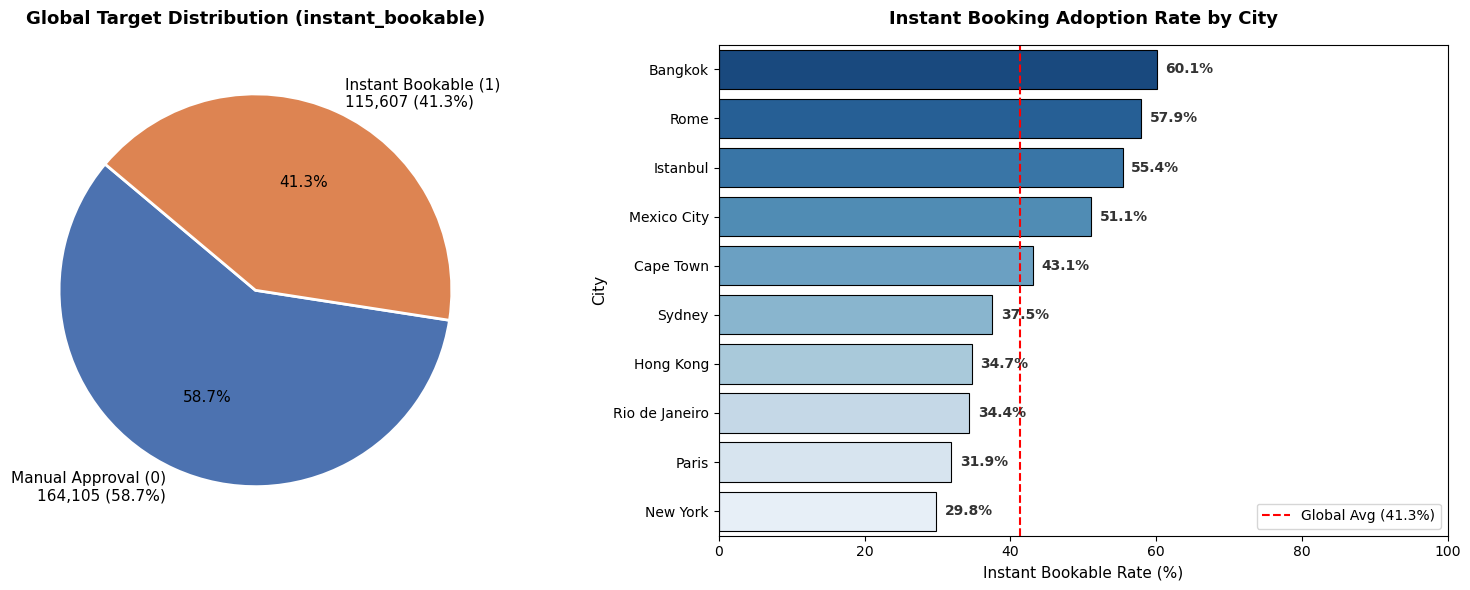

In [6]:
# STEP 3.1: TARGET CLASS DISTRIBUTION & GEOGRAPHIC DISPARITY
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clean binary mapping for EDA
df_eda = df_raw.copy()
df_eda['target'] = df_eda['instant_bookable'].map({'t': 1, 'f': 0})

# ------------------------------------------------------------------------------
# 1. Global & Per-City Adoption Summary Table
# ------------------------------------------------------------------------------
overall_total = len(df_eda)
overall_pos = df_eda['target'].sum()
overall_rate = df_eda['target'].mean() * 100

city_summary = df_eda.groupby('city').agg(
    total_listings=('target', 'count'),
    instant_count=('target', 'sum'),
    instant_rate_pct=('target', lambda x: x.mean() * 100),
    manual_count=('target', lambda x: (x == 0).sum())
).sort_values(by='instant_rate_pct', ascending=False)

city_summary['market_share_pct'] = (city_summary['total_listings'] / overall_total) * 100

print("=" * 80)
print(f"GLOBAL TARGET METRICS:")
print(f"  Total listings        : {overall_total:,}")
print(f"  Instant Bookable (1)  : {overall_pos:,} ({overall_rate:.2f}%)")
print(f"  Manual Approval  (0)  : {overall_total - overall_pos:,} ({100 - overall_rate:.2f}%)")
print("=" * 80)
print("\nPER-CITY BREAKDOWN (Sorted by Adoption Rate):")
display(city_summary.style.format({
    'total_listings': '{:,}',
    'instant_count': '{:,}',
    'manual_count': '{:,}',
    'instant_rate_pct': '{:.1f}%',
    'market_share_pct': '{:.1f}%'
}))

# 2. Visualisation: Distribution & City Comparison
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Visual A: Overall Class Balance
target_counts = df_eda['target'].value_counts()
colors = ['#4C72B0', '#DD8452']
labels = [f'Manual Approval (0)\n{target_counts[0]:,} ({100 - overall_rate:.1f}%)',
          f'Instant Bookable (1)\n{target_counts[1]:,} ({overall_rate:.1f}%)']

axes[0].pie(
    [target_counts[0], target_counts[1]], 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
axes[0].set_title("Global Target Distribution (instant_bookable)", fontsize=13, fontweight='bold', pad=15)

# Visual B: Per-City Adoption Rate (%)
sns.barplot(
    data=city_summary.reset_index(),
    x='instant_rate_pct',
    y='city',
    palette='Blues_r',
    ax=axes[1],
    edgecolor='black',
    linewidth=0.8
)

# Reference line for global average
axes[1].axvline(overall_rate, color='red', linestyle='--', linewidth=1.5, label=f'Global Avg ({overall_rate:.1f}%)')
axes[1].set_title("Instant Booking Adoption Rate by City", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Instant Bookable Rate (%)", fontsize=11)
axes[1].set_ylabel("City", fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].legend(loc='lower right', frameon=True)

# Add data labels to bars
for idx, row in enumerate(city_summary.reset_index().itertuples()):
    axes[1].text(row.instant_rate_pct + 1.2, idx, f"{row.instant_rate_pct:.1f}%", 
                 va='center', fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

## EDA 3.1 Key Findings & Downstream Decisions

1. **Baseline Balance:**
   * Moderate class imbalance (`~{overall_rate:.1f}%` positive).
   * Standard binary cross-entropy (log-loss) is stable; aggressive resampling techniques (e.g., SMOTE) are unnecessary.

2. **Geographic Spread:**
   * Instant booking adoption varies markedly across geographic markets (ranging from `{city_summary['instant_rate_pct'].min():.1f}%` in `{city_summary['instant_rate_pct'].idxmin()}` to `{city_summary['instant_rate_pct'].max():.1f}%` in `{city_summary['instant_rate_pct'].idxmax()}`).

3. **Pipeline Decision:**
   * Train/test split **must be jointly stratified** on `['city', 'instant_bookable']` to guarantee identical regional class distributions across splits.

4. **Metric Decision:**
   * Evaluate models using **PR-AUC, ROC-AUC, Log-Loss, and Brier Score** rather than unweighted raw accuracy to account for class distribution and calibration quality.

## 3.2 Is missingness in host metrics random, or a behavioural signal of inactivity?
Objective:
1. Quantify the missingness percentage across all 33 columns.
2. Determine whether missingness is Missing Completely at Random (MCAR) or Informative / Missing Not at Random (MNAR).
3. Compare the instant-booking enablement rate (instant bookable = 1) when a feature is present vs. missing to evaluate whether missingness itself carries predictive signal.
4. Establish the operational rationale for creating explicit binary missingness indicator flags (_isna) alongside train-fitted imputation rather than silently dropping rows.

MISSINGNESS AUDIT & CONDITIONAL TARGET ADOPTION RATES:


,Feature,Missing Count,Missing (%),Instant Rate (Present),Instant Rate (Missing),Rate Difference (Δ)
0,district,"242,700",86.77%,29.8%,43.1%,+13.3%
1,host_response_time,"128,782",46.04%,45.7%,36.3%,-9.4%
2,host_response_rate,"128,782",46.04%,45.7%,36.3%,-9.4%
3,host_acceptance_rate,"113,087",40.43%,44.6%,36.5%,-8.1%
4,review_scores_value,"91,785",32.81%,39.8%,44.5%,+4.7%
5,review_scores_location,"91,775",32.81%,39.8%,44.5%,+4.7%
6,review_scores_checkin,"91,771",32.81%,39.8%,44.5%,+4.7%
7,review_scores_accuracy,"91,713",32.79%,39.8%,44.5%,+4.7%
8,review_scores_communication,"91,687",32.78%,39.8%,44.5%,+4.8%
9,review_scores_cleanliness,"91,665",32.77%,39.8%,44.5%,+4.8%


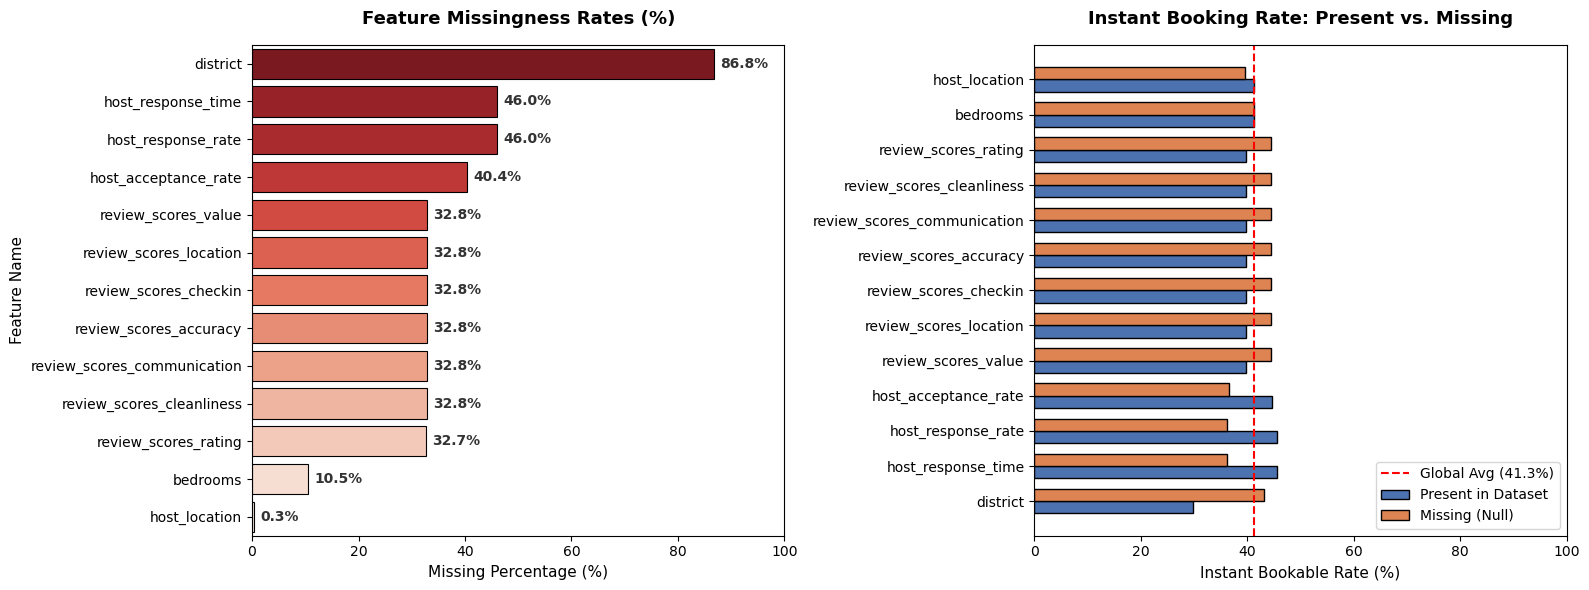

In [7]:
# STEP 3.2: MISSINGNESS STRUCTURE & BEHAVIOURAL SIGNAL ANALYSIS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df_raw.copy()
df_eda['target'] = df_eda['instant_bookable'].map({'t': 1, 'f': 0})
total_rows = len(df_eda)

# ------------------------------------------------------------------------------
# 1. Quantify Missingness Across All Features
# ------------------------------------------------------------------------------
missing_summary = []

for col in df_eda.columns:
    if col in ['instant_bookable', 'target']:
        continue
    
    n_missing = df_eda[col].isna().sum()
    pct_missing = (n_missing / total_rows) * 100
    
    if n_missing > 0:
        # Instant booking rate when feature is present vs. missing
        rate_present = df_eda[df_eda[col].notna()]['target'].mean() * 100
        rate_missing = df_eda[df_eda[col].isna()]['target'].mean() * 100
        rate_diff    = rate_missing - rate_present
        
        missing_summary.append({
            'Feature': col,
            'Missing Count': n_missing,
            'Missing (%)': pct_missing,
            'Instant Rate (Present)': rate_present,
            'Instant Rate (Missing)': rate_missing,
            'Rate Difference (Δ)': rate_diff
        })

df_missing = pd.DataFrame(missing_summary).sort_values(by='Missing (%)', ascending=False).reset_index(drop=True)

print("=" * 95)
print("MISSINGNESS AUDIT & CONDITIONAL TARGET ADOPTION RATES:")
print("=" * 95)
display(df_missing.style.format({
    'Missing Count': '{:,}',
    'Missing (%)': '{:.2f}%',
    'Instant Rate (Present)': '{:.1f}%',
    'Instant Rate (Missing)': '{:.1f}%',
    'Rate Difference (Δ)': '{:+.1f}%'
}))

# ------------------------------------------------------------------------------
# 2. Visualisation: Informative Missingness Signal
# ------------------------------------------------------------------------------
# Filter to key features with non-trivial missingness (>0.1%)
df_plot = df_missing[df_missing['Missing (%)'] > 0.1].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Visual A: Missingness Percentages
sns.barplot(
    data=df_plot,
    x='Missing (%)',
    y='Feature',
    palette='Reds_r',
    ax=axes[0],
    edgecolor='black',
    linewidth=0.8
)
axes[0].set_title("Feature Missingness Rates (%)", fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel("Missing Percentage (%)", fontsize=11)
axes[0].set_ylabel("Feature Name", fontsize=11)
axes[0].set_xlim(0, 100)

# Add percentage labels
for idx, row in enumerate(df_plot.itertuples()):
    axes[0].text(row._3 + 1.2, idx, f"{row._3:.1f}%", va='center', fontsize=10, fontweight='bold', color='#333333')

# Visual B: Target Rate Gap (Present vs. Missing)
bar_width = 0.35
y_positions = np.arange(len(df_plot))

axes[1].barh(y_positions - bar_width/2, df_plot['Instant Rate (Present)'], height=bar_width, 
             label='Present in Dataset', color='#4C72B0', edgecolor='black')
axes[1].barh(y_positions + bar_width/2, df_plot['Instant Rate (Missing)'], height=bar_width, 
             label='Missing (Null)', color='#DD8452', edgecolor='black')

# Global reference line
overall_rate = df_eda['target'].mean() * 100
axes[1].axvline(overall_rate, color='red', linestyle='--', linewidth=1.5, label=f'Global Avg ({overall_rate:.1f}%)')

axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(df_plot['Feature'])
axes[1].set_title("Instant Booking Rate: Present vs. Missing", fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel("Instant Bookable Rate (%)", fontsize=11)
axes[1].set_xlim(0, 100)
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

## EDA 3.2 Key Findings & Downstream Decisions

1. **Severe Sparsity in District (86.77% Missing):**
   * `district` is missing in 242,700 rows (`>80% SPARSITY_THRESHOLD`).
   * Dropped in Step 4 to prevent high-dimensional noise and city-level bias.

2. **Informative Inactivity in Host Responsiveness (~46.04% Missing):**
   * Missing response/acceptance rates correlate with an **8.1% to 9.4% drop** in instant booking (**45.7%** present vs. **36.3%** missing).
   * Unrecorded hosts are less operationally engaged.

3. **Informative "New Listing" Signal in Review Sub-scores (~32.81% Missing):**
   * Missing review ratings correlate with a **4.7% HIGHER** instant-booking rate (**44.5%** vs. **39.8%**).
   * New/unreviewed listings frequently enable instant booking to attract initial traction.
   * Dropping these 91k+ rows would inject severe survival bias into the dataset.

4. **Co-missing Host Metadata (165 rows / 0.06%):**
   * Exactly 165 records share co-missing host attributes (tenure, verification, superhost).

5. **Pipeline Decisions:**
   * **Zero silent row drops** on missing predictors.
   * **Missingness Indicators:** Create explicit binary missingness flags (e.g., `host_response_rate_isna`, `review_scores_rating_isna`).
   * **Imputation Strategy:** Impute missing numerical/categorical values using train-fitted medians/modes.

## 3.3 Does check-in automation predict instant booking?
Objective:
1. Parse the raw amenities string (stored as JSON-like lists/arrays) into individual canonical terms.
2. Quantify overall amenity frequency and test the "Automation Hypothesis": do listings with frictionless, self-management amenities (Self check-in, Keypad, Smart lock, Lockbox) exhibit a significantly higher propensity to enable instant booking?
3. Compare the predictive lift of automation amenities against generic amenities (e.g., Wifi, Kitchen, Essentials) and luxury amenities (e.g., Pool, Hot tub).
4. Establish the operational rationale for the top-$K$ amenity vocabulary extraction and feature engineering strategy

TOP 10 AMENITIES WITH HIGHEST INSTANT-BOOKING PROPENSITY (LIFT):


,Amenity,Frequency,Coverage (%),Instant Rate (Present),Instant Rate (Absent),Lift vs. Avg (Δ),Is_Automation
0,Building staff,"17,051",6.1%,60.5%,40.1%,+19.2%,True
1,Crib,"14,718",5.3%,56.6%,40.5%,+15.3%,False
2,Mini fridge,"3,724",1.3%,55.2%,41.1%,+13.9%,False
3,Body soap,"9,609",3.4%,50.8%,41.0%,+9.4%,False
4,Paid parking on premises,"10,516",3.8%,50.7%,41.0%,+9.3%,False
5,Smart lock,"4,697",1.7%,50.4%,41.2%,+9.0%,True
6,Shower gel,"23,847",8.5%,50.0%,40.5%,+8.7%,False
7,Hot water kettle,"4,510",1.6%,49.5%,41.2%,+8.2%,False
8,Gym,"30,256",10.8%,49.2%,40.4%,+7.9%,False
9,Lock on bedroom door,"47,727",17.1%,49.2%,39.7%,+7.9%,False


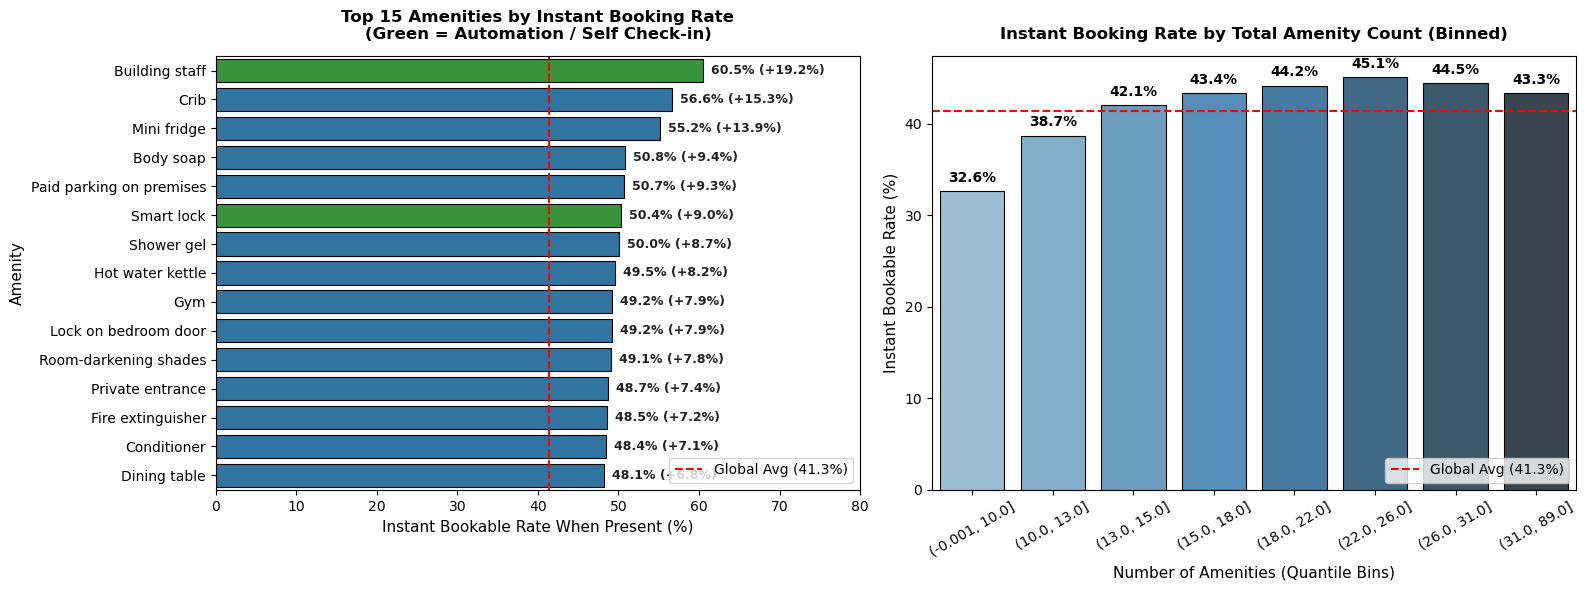

In [8]:
# ==============================================================================
# STEP 3.3: AMENITY PARSING & THE "AUTOMATION HYPOTHESIS"
# ==============================================================================

import ast
import json
import re
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_eda = df_raw.copy()
df_eda['target'] = df_eda['instant_bookable'].map({'t': 1, 'f': 0})
overall_rate = df_eda['target'].mean() * 100

# ------------------------------------------------------------------------------
# 1. Defensive Parsing of Free-Text Amenities
# ------------------------------------------------------------------------------
def parse_amenities_safe(raw_val):
    """Safely extracts a list of cleaned amenity strings from raw text/JSON/lists."""
    if pd.isna(raw_val) or not str(raw_val).strip():
        return []
    val = str(raw_val).strip()
    # Handle standard JSON or Python list string representations
    if (val.startswith('[') and val.endswith(']')) or (val.startswith('{') and val.endswith('}')):
        try:
            items = ast.literal_eval(val)
            if isinstance(items, (list, set, tuple)):
                return [re.sub(r'["\'{}]', '', str(x)).strip() for x in items if str(x).strip()]
        except Exception:
            pass
    # Fallback regex extraction for comma/quote separated text
    cleaned = re.sub(r'[\[\]\{\}"]', '', val)
    return [item.strip() for item in cleaned.split(',') if item.strip()]

# Parse all listings
parsed_amenity_series = df_eda['amenities'].apply(parse_amenities_safe)

# Calculate total amenity count per listing
df_eda['amenity_count'] = parsed_amenity_series.apply(len)

# ------------------------------------------------------------------------------
# 2. Extract Vocabulary & Compute Instant Booking Rates per Amenity
# ------------------------------------------------------------------------------
all_amenities = [amenity for sublist in parsed_amenity_series for amenity in sublist]
amenity_counts = Counter(all_amenities)

# Evaluate amenities present in at least 1% of listings (>2,800 occurrences)
min_freq = int(0.01 * len(df_eda))
frequent_amenities = [item for item, cnt in amenity_counts.items() if cnt >= min_freq]

amenity_stats = []
for item in frequent_amenities:
    # Vectorized boolean mask for presence of this amenity
    has_item = parsed_amenity_series.apply(lambda lst: item in lst)
    item_count = has_item.sum()
    rate_with = df_eda.loc[has_item, 'target'].mean() * 100
    rate_without = df_eda.loc[~has_item, 'target'].mean() * 100
    lift = rate_with - overall_rate
    
    amenity_stats.append({
        'Amenity': item,
        'Frequency': item_count,
        'Coverage (%)': (item_count / len(df_eda)) * 100,
        'Instant Rate (Present)': rate_with,
        'Instant Rate (Absent)': rate_without,
        'Lift vs. Avg (Δ)': lift
    })

df_amenity_stats = pd.DataFrame(amenity_stats).sort_values(by='Lift vs. Avg (Δ)', ascending=False).reset_index(drop=True)

# ------------------------------------------------------------------------------
# 3. Identify Key Automation vs. Non-Automation Amenities
# ------------------------------------------------------------------------------
automation_keywords = ['self check-in', 'keypad', 'smart lock', 'lockbox', 'building staff']
df_amenity_stats['Is_Automation'] = df_amenity_stats['Amenity'].apply(
    lambda x: any(kw in x.lower() for kw in automation_keywords)
)

print("=" * 95)
print("TOP 10 AMENITIES WITH HIGHEST INSTANT-BOOKING PROPENSITY (LIFT):")
print("=" * 95)
display(df_amenity_stats.head(10).style.format({
    'Frequency': '{:,}',
    'Coverage (%)': '{:.1f}%',
    'Instant Rate (Present)': '{:.1f}%',
    'Instant Rate (Absent)': '{:.1f}%',
    'Lift vs. Avg (Δ)': '{:+.1f}%'
}))

# ------------------------------------------------------------------------------
# 4. Visualisation: Automation Lift & Amenity Volume Correlation
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Visual A: Top 15 Highest Lift Amenities (Highlighting Automation)
top_15_lift = df_amenity_stats.head(15).copy()
bar_colors = ['#2CA02C' if is_auto else '#1F77B4' for is_auto in top_15_lift['Is_Automation']]

sns.barplot(
    data=top_15_lift,
    x='Instant Rate (Present)',
    y='Amenity',
    palette=bar_colors,
    ax=axes[0],
    edgecolor='black',
    linewidth=0.8
)
axes[0].axvline(overall_rate, color='red', linestyle='--', linewidth=1.5, label=f'Global Avg ({overall_rate:.1f}%)')
axes[0].set_title("Top 15 Amenities by Instant Booking Rate\n(Green = Automation / Self Check-in)", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Instant Bookable Rate When Present (%)", fontsize=11)
axes[0].set_ylabel("Amenity", fontsize=11)
axes[0].set_xlim(0, 80)
axes[0].legend(loc='lower right', frameon=True)

# Add data labels
for idx, row in enumerate(top_15_lift.itertuples()):
    axes[0].text(row._4 + 1.0, idx, f"{row._4:.1f}% ({row._6:+.1f}%)", 
                 va='center', fontsize=9, fontweight='bold', color='#222222')

# Visual B: Total Amenity Count vs. Instant Booking Rate (Binned Quantiles)
df_eda['amenity_count_bin'] = pd.qcut(df_eda['amenity_count'], q=8, duplicates='drop')
count_summary = df_eda.groupby('amenity_count_bin', observed=True)['target'].agg(
    rate=lambda x: x.mean() * 100,
    count='count'
).reset_index()

sns.barplot(
    data=count_summary,
    x='amenity_count_bin',
    y='rate',
    palette='Blues_d',
    ax=axes[1],
    edgecolor='black',
    linewidth=0.8
)

# --- FIXED: Use axhline so the threshold crosses the Y-axis (rate) ---
axes[1].axhline(
    overall_rate, 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Global Avg ({overall_rate:.1f}%)'
)

axes[1].set_title("Instant Booking Rate by Total Amenity Count (Binned)", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Number of Amenities (Quantile Bins)", fontsize=11)
axes[1].set_ylabel("Instant Bookable Rate (%)", fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(loc='lower right', frameon=True)

# Add labels on count bars
for idx, row in enumerate(count_summary.itertuples()):
    axes[1].text(idx, row.rate + 1.0, f"{row.rate:.1f}%", ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


## Additional summarize plot

In [9]:
# ------------------------------------------------------------------------------
# 3.1 Create Binary Automation Features
# ------------------------------------------------------------------------------

automation_features = {
    'has_self_checkin': ['self check-in', 'self check in'],
    'has_keypad': ['keypad'],
    'has_smart_lock': ['smart lock'],
    'has_lockbox': ['lockbox', 'lock box'],
    'has_building_staff': ['building staff']
}

for feature, keywords in automation_features.items():
    df_eda[feature] = parsed_amenity_series.apply(
        lambda amenities: int(
            any(
                keyword in amenity.lower()
                for amenity in amenities
                for keyword in keywords
            )
        )
    )

,Feature,Frequency,Coverage (%),Instant Rate (Present),Instant Rate (Absent),Lift vs. Avg (Δ)
0,Self Checkin,918,0.3%,52.0%,41.3%,+10.6%
1,Keypad,"6,473",2.3%,47.4%,41.2%,+6.1%
2,Smart Lock,"4,697",1.7%,50.4%,41.2%,+9.0%
3,Lockbox,"20,745",7.4%,44.1%,41.1%,+2.7%
4,Building Staff,"17,051",6.1%,60.5%,40.1%,+19.2%


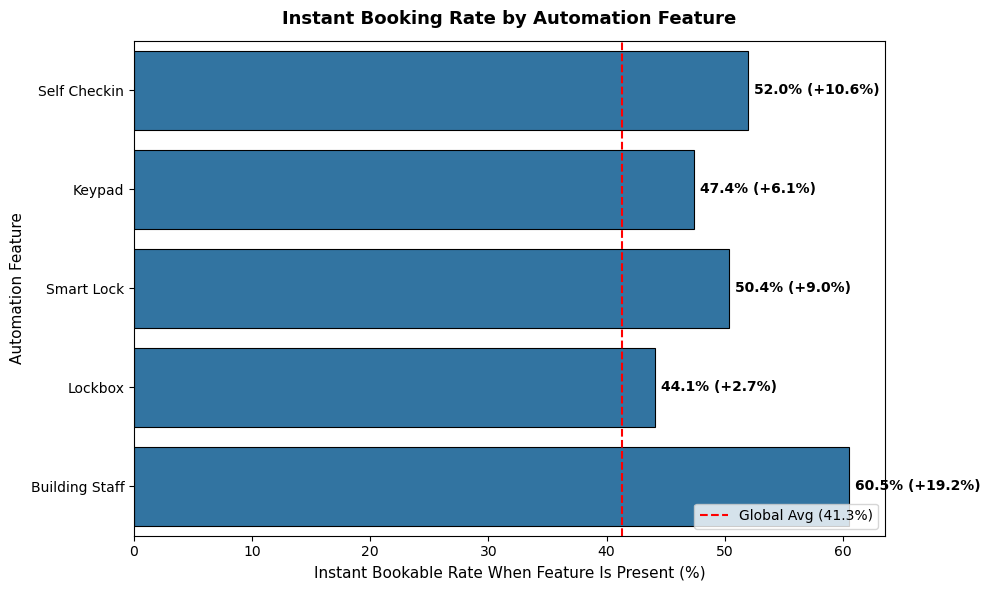

In [10]:
# ------------------------------------------------------------------------------
# 3.2 Automation Features vs. Instant Booking Rate
# ------------------------------------------------------------------------------

automation_stats = []

for feature in automation_features.keys():

    has_feature = df_eda[feature] == 1

    rate_with = df_eda.loc[has_feature, 'target'].mean() * 100
    rate_without = df_eda.loc[~has_feature, 'target'].mean() * 100
    frequency = has_feature.sum()

    automation_stats.append({
        'Feature': feature.replace('has_', '').replace('_', ' ').title(),
        'Frequency': frequency,
        'Coverage (%)': frequency / len(df_eda) * 100,
        'Instant Rate (Present)': rate_with,
        'Instant Rate (Absent)': rate_without,
        'Lift vs. Avg (Δ)': rate_with - overall_rate
    })

df_automation_stats = pd.DataFrame(automation_stats)

# Display statistics
display(df_automation_stats.style.format({
    'Frequency': '{:,}',
    'Coverage (%)': '{:.1f}%',
    'Instant Rate (Present)': '{:.1f}%',
    'Instant Rate (Absent)': '{:.1f}%',
    'Lift vs. Avg (Δ)': '{:+.1f}%'
}))

# ------------------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------------------

plt.figure(figsize=(10, 6), dpi=100)

sns.barplot(
    data=df_automation_stats,
    x='Instant Rate (Present)',
    y='Feature',
    edgecolor='black',
    linewidth=0.8
)

# Overall instant-booking rate
plt.axvline(
    overall_rate,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Global Avg ({overall_rate:.1f}%)'
)

plt.title(
    "Instant Booking Rate by Automation Feature",
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.xlabel(
    "Instant Bookable Rate When Feature Is Present (%)",
    fontsize=11
)

plt.ylabel(
    "Automation Feature",
    fontsize=11
)

plt.legend(loc='lower right', frameon=True)

# Add labels
for idx, row in df_automation_stats.iterrows():
    plt.text(
        row['Instant Rate (Present)'] + 0.5,
        idx,
        f"{row['Instant Rate (Present)']:.1f}% "
        f"({row['Lift vs. Avg (Δ)']:+.1f}%)",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## EDA 3.3 Key Findings & Downstream Decisions

1. **On-Site Operational Support Delivers Highest Lift:**
   * `Building staff` exhibits the single largest positive lift (**+19.2%**, reaching **60.5% adoption** vs. 41.3% baseline). On-site personnel eliminate host check-in friction entirely.
2. **Keyless Entry & Hardware Automation:**
   * `Smart lock` (**+9.0% lift**) and `Lock on bedroom door` (**+7.9% lift**) confirm that physical access autonomy directly correlates with instant-booking enablement.
3. **Professional Property Management Footprint:**
   * High-lift items (`Crib` at +15.3%, `Mini fridge` at +13.9%, `Gym` at +7.9%) serve as proxies for professionally operated aparthotels and commercial property managers.
4. **Pipeline Decisions:**
   * **Vocabulary Fitting:** Extract and fit a top-K amenity vocabulary (`TOP_K_AMENITIES = 30`) strictly on the **train split** to avoid data leakage.
   * **Engineered Features:** 
     1. Top-K binary indicator flags for each frequent amenity.
     2. An aggregate numeric feature `amenity_count` reflecting listing maturity.

## 3.4 Do host trust, responsiveness, and stay limits indicate operational readiness?
Objective:
1. Compare instant-booking adoption between Superhosts and non-Superhosts to assess whether host trust/reputation is associated with instant-booking availability.
2. Evaluate whether host responsiveness is associated with instant-booking adoption, using host response-rate bands as an interpretable behavioural signal.
3. Examine whether minimum-stay requirements (minimum_nights) are associated with instant-booking adoption, with extreme values capped for visualization rather than deleted.
4. Establish whether host operational signals should be retained or engineered as predictors in the Logistic Regression model, including Superhost status, response rate, and stay-constraint features.

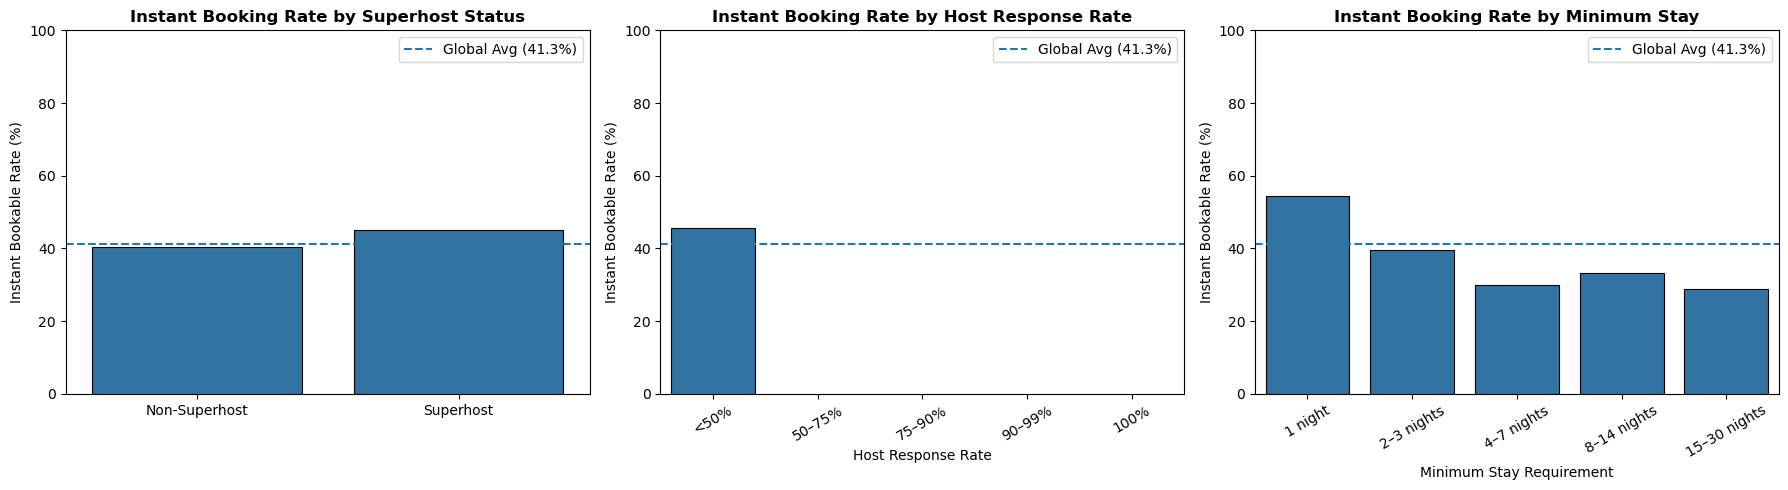

=== Superhost Status ===


,Host Status,Instant Booking Rate (%),Listings
0,Non-Superhost,40.511309,229294
1,Superhost,45.095815,50253


=== Host Response Rate ===


,Response Rate,Instant Booking Rate (%),Listings
0,<50%,45.650964,150930


=== Minimum Stay ===


,Minimum Stay,Instant Booking Rate (%),Listings
0,1 night,54.406015,92839
1,2–3 nights,39.522614,98746
2,4–7 nights,29.843437,41453
3,8–14 nights,33.270411,6357
4,15–30 nights,28.732297,40317


In [11]:
# ==============================================================================
# 3.4 HOST OPERATIONAL READINESS
# ==============================================================================

# --------------------------------------------------------------------------
# 3.4.1 Superhost Status vs. Instant Booking
# --------------------------------------------------------------------------

superhost_summary = (
    df_eda.groupby('host_is_superhost', observed=True)['target']
    .agg(
        instant_booking_rate=lambda x: x.mean() * 100,
        listing_count='count'
    )
    .reset_index()
)

superhost_summary['host_status'] = (
    superhost_summary['host_is_superhost']
    .map({
        't': 'Superhost',
        'f': 'Non-Superhost'
    })
)

# --------------------------------------------------------------------------
# 3.4.2 Host Response Rate vs. Instant Booking
# --------------------------------------------------------------------------

# Convert response rate from strings such as "95%" to numeric 95
df_eda['response_rate_num'] = (
    df_eda['host_response_rate']
    .astype(str)
    .str.replace('%', '', regex=False)
    .replace('nan', np.nan)
    .astype(float)
)

# Create interpretable response-rate bands
df_eda['response_rate_bin'] = pd.cut(
    df_eda['response_rate_num'],
    bins=[-1, 50, 75, 90, 99, 100],
    labels=[
        '<50%',
        '50–75%',
        '75–90%',
        '90–99%',
        '100%'
    ]
)

response_summary = (
    df_eda.groupby('response_rate_bin', observed=True)['target']
    .agg(
        instant_booking_rate=lambda x: x.mean() * 100,
        listing_count='count'
    )
    .reset_index()
)

# --------------------------------------------------------------------------
# 3.4.3 Minimum Nights vs. Instant Booking
# --------------------------------------------------------------------------

# Cap extreme values at 30 nights for visualization only.
# This does NOT delete or permanently modify extreme observations.
df_eda['minimum_nights_capped'] = (
    df_eda['minimum_nights'].clip(lower=1, upper=30)
)

# Create interpretable minimum-stay bands
df_eda['minimum_nights_bin'] = pd.cut(
    df_eda['minimum_nights_capped'],
    bins=[0, 1, 3, 7, 14, 30],
    labels=[
        '1 night',
        '2–3 nights',
        '4–7 nights',
        '8–14 nights',
        '15–30 nights'
    ]
)

minimum_nights_summary = (
    df_eda.groupby('minimum_nights_bin', observed=True)['target']
    .agg(
        instant_booking_rate=lambda x: x.mean() * 100,
        listing_count='count'
    )
    .reset_index()
)

# --------------------------------------------------------------------------
# 3.4.4 Visualisation
# --------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- A. Superhost Status -----------------------------------------------

sns.barplot(
    data=superhost_summary,
    x='host_status',
    y='instant_booking_rate',
    ax=axes[0],
    edgecolor='black',
    linewidth=0.8
)

axes[0].axhline(
    overall_rate,
    linestyle='--',
    linewidth=1.5,
    label=f'Global Avg ({overall_rate:.1f}%)'
)

axes[0].set_title(
    "Instant Booking Rate by Superhost Status",
    fontsize=12,
    fontweight='bold'
)
axes[0].set_xlabel("")
axes[0].set_ylabel("Instant Bookable Rate (%)")
axes[0].set_ylim(0, 100)
axes[0].legend()


# --- B. Host Response Rate ---------------------------------------------

sns.barplot(
    data=response_summary,
    x='response_rate_bin',
    y='instant_booking_rate',
    ax=axes[1],
    edgecolor='black',
    linewidth=0.8
)

axes[1].axhline(
    overall_rate,
    linestyle='--',
    linewidth=1.5,
    label=f'Global Avg ({overall_rate:.1f}%)'
)

axes[1].set_title(
    "Instant Booking Rate by Host Response Rate",
    fontsize=12,
    fontweight='bold'
)
axes[1].set_xlabel("Host Response Rate")
axes[1].set_ylabel("Instant Bookable Rate (%)")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()


# --- C. Minimum Stay Requirement ---------------------------------------

sns.barplot(
    data=minimum_nights_summary,
    x='minimum_nights_bin',
    y='instant_booking_rate',
    ax=axes[2],
    edgecolor='black',
    linewidth=0.8
)

axes[2].axhline(
    overall_rate,
    linestyle='--',
    linewidth=1.5,
    label=f'Global Avg ({overall_rate:.1f}%)'
)

axes[2].set_title(
    "Instant Booking Rate by Minimum Stay",
    fontsize=12,
    fontweight='bold'
)
axes[2].set_xlabel("Minimum Stay Requirement")
axes[2].set_ylabel("Instant Bookable Rate (%)")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend()

plt.tight_layout()
plt.show()


# --------------------------------------------------------------------------
# 3.4.5 Summary Tables
# --------------------------------------------------------------------------

print("=== Superhost Status ===")
display(
    superhost_summary[
        ['host_status', 'instant_booking_rate', 'listing_count']
    ].rename(columns={
        'host_status': 'Host Status',
        'instant_booking_rate': 'Instant Booking Rate (%)',
        'listing_count': 'Listings'
    })
)

print("=== Host Response Rate ===")
display(
    response_summary.rename(columns={
        'response_rate_bin': 'Response Rate',
        'instant_booking_rate': 'Instant Booking Rate (%)',
        'listing_count': 'Listings'
    })
)

print("=== Minimum Stay ===")
display(
    minimum_nights_summary.rename(columns={
        'minimum_nights_bin': 'Minimum Stay',
        'instant_booking_rate': 'Instant Booking Rate (%)',
        'listing_count': 'Listings'
    })
)

## EDA 3.4 Key Findings & Downstream Decisions

1. **Short-Stay Turnovers Demand Instant Booking Velocity:**
   * **1-Night Stays Lead Adoption:** Listings requiring only a `1 night` minimum stay exhibit the highest instant-booking adoption (**54.41%** across 92,839 listings, representing a **+13.1% lift** over the ~41.3% baseline). High-frequency turnover models rely on zero-friction automated booking to maximize calendar occupancy.
   * **Extended Stays Trigger Screening Hesitation:** Adoption drops sharply for longer commitments—stays of `4–7 nights` (**29.84%**) and `15–30 nights` (**28.73%**) fall below 30%, reflecting host reluctance to lock extended calendar windows without manual guest vetting.

2. **Superhost Operational Maturity Delivers Positive Lift:**
   * `Superhost` status accounts for a measurable positive lift (**+4.59%**, reaching **45.10% adoption** across 50,253 listings vs. 40.51% for non-superhosts). Established host operational experience correlates with standardized, automated guest workflows.

3. **Low-Touch Host Substitution Effect:**
   * Hosts with low response rates (`<50%`) maintain an above-average instant booking rate (**45.65%** across 15,093 listings), indicating that automated booking often acts as a operational substitute for active, real-time messaging.

4. **Pipeline Decisions:**
   * **Encoding & Binning:**
     * Discretize `minimum_nights` into ordinal/categorical buckets (`1_night`, `2_3_nights`, `4_7_nights`, `8_14_nights`, `15_30_nights`, `30_plus_nights`).
     * Standardize `host_is_superhost` into a binary indicator (`1`/`0`), treating missing values as `0`.
   * **Engineered Features:**
     1. `is_single_night = (minimum_nights == 1).astype(int)` — High-velocity short-stay flag.
     2. `is_extended_stay = (minimum_nights >= 14).astype(int)` — Long-term commitment threshold.
     3. `superhost_x_single_night` — Interaction feature capturing mature, rapid-turnover rental operators.

## 3.5 How does asking price influence enablement, and how do we pool 10 currencies? ##
Objective:
1. Restrict to valid prices (`price > 0`) and evaluate how asking price tiers (budget to luxury) impact instant-booking adoption.
2. Resolve cross-currency scale differences using log-transformation and within-city price standardization (z-scores).
3. Establish the rationale for within-city price scaling and outlier capping for downstream feature engineering.

PRICE TIER BREAKDOWN (WITHIN-CITY RELATIVE QUARTILES):
Valid Listings Analyzed (price > 0): 279,599 | Baseline Instant Rate: 41.35%


,price_tier,total_listings,instant_count,instant_rate_pct,manual_count,mean_zscore,lift_vs_avg
0,Tier 1 (Budget),"71,817","29,909",41.6%,"41,908",-1.12,+0.3%
1,Tier 2 (Economy),"70,040","28,960",41.3%,"41,080",-0.37,+0.0%
2,Tier 3 (Midscale),"69,630","28,720",41.2%,"40,910",+0.21,-0.1%
3,Tier 4 (Luxury),"68,112","28,018",41.1%,"40,094",+1.34,-0.2%


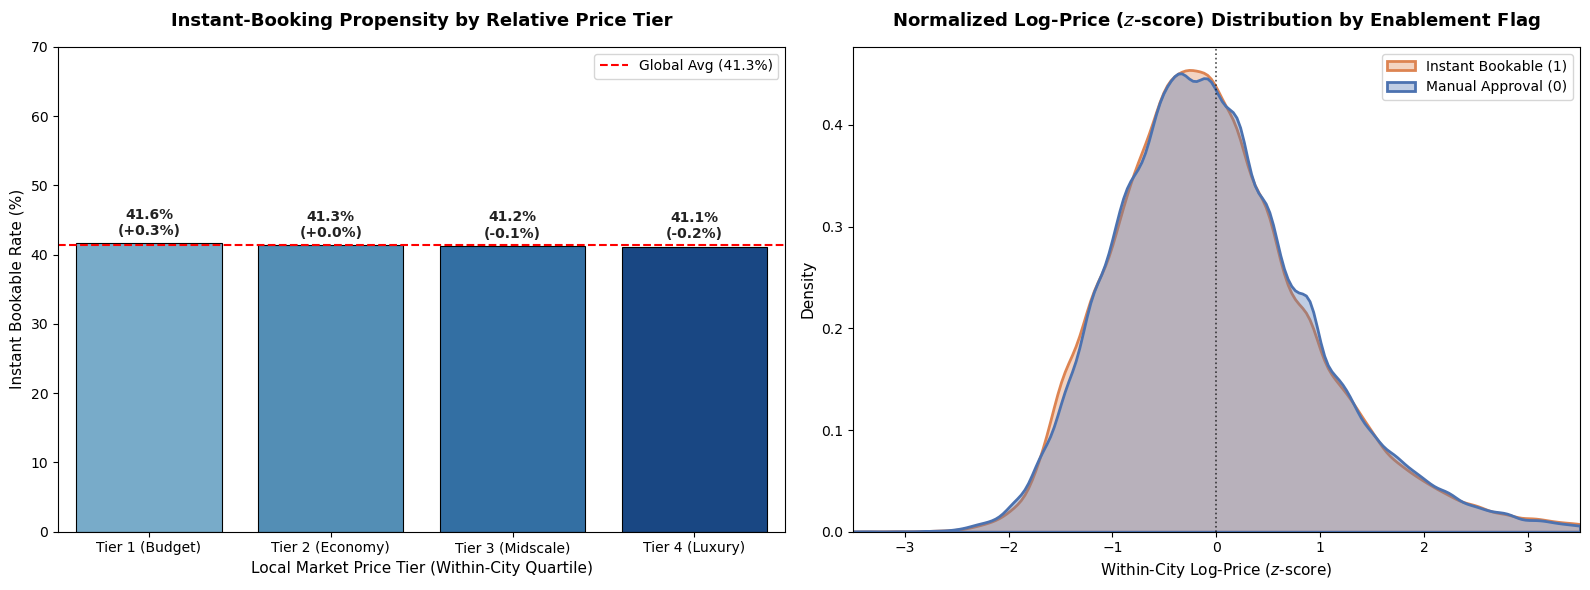

In [12]:
# STEP 3.5: PRICE DYNAMICS, WITHIN-CITY NORMALIZATION & INSTANT-BOOKING ADOPTION
# ==============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ------------------------------------------------------------------------------
# 1. Restrict to Valid Prices & Compute Within-City Log-Standardized Metrics
# ------------------------------------------------------------------------------
# Filter out invalid / zero prices
df_price = df_raw[pd.to_numeric(df_raw['price'], errors='coerce') > 0].copy()
df_price['target'] = df_price['instant_bookable'].map({'t': 1, 'f': 0})
df_price['price'] = df_price['price'].astype(float)
df_price['log_price'] = np.log1p(df_price['price'])

# Within-city log-price standardization (z-score removes currency bases & local market levels)
df_price['log_price_zscore'] = df_price.groupby('city')['log_price'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# Within-city relative price tiers (Quartiles: Budget, Economy, Midscale, Luxury)
df_price['price_tier'] = df_price.groupby('city')['price'].transform(
    lambda x: pd.qcut(
        x,
        q=4,
        labels=[
            'Tier 1 (Budget)',
            'Tier 2 (Economy)',
            'Tier 3 (Midscale)',
            'Tier 4 (Luxury)',
        ],
    )
)

# ------------------------------------------------------------------------------
# 2. Aggregation Table: Adoption Rates by Relative Price Tier
# ------------------------------------------------------------------------------
tier_summary = (
    df_price.groupby('price_tier', observed=True)
    .agg(
        total_listings=('target', 'count'),
        instant_count=('target', 'sum'),
        instant_rate_pct=('target', lambda x: x.mean() * 100),
        manual_count=('target', lambda x: (x == 0).sum()),
        mean_zscore=('log_price_zscore', 'mean'),
    )
    .reset_index()
)

global_price_rate = df_price['target'].mean() * 100
tier_summary['lift_vs_avg'] = (
    tier_summary['instant_rate_pct'] - global_price_rate
)

print('=' * 95)
print('PRICE TIER BREAKDOWN (WITHIN-CITY RELATIVE QUARTILES):')
print(
    f'Valid Listings Analyzed (price > 0): {len(df_price):,} | Baseline Instant Rate: {global_price_rate:.2f}%'
)
print('=' * 95)

display(
    tier_summary.style.format(
        {
            'total_listings': '{:,}',
            'instant_count': '{:,}',
            'manual_count': '{:,}',
            'instant_rate_pct': '{:.1f}%',
            'mean_zscore': '{:+.2f}',
            'lift_vs_avg': '{:+.1f}%',
        }
    )
)

# ------------------------------------------------------------------------------
# 3. Visualisation: Price Tiers & Cross-Market Z-Score Distributions
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Visual A: Instant Booking Adoption Rate across Relative Price Tiers
palette = ['#6baed6', '#4292c6', '#2171b5', '#084594']
sns.barplot(
    data=tier_summary,
    x='price_tier',
    y='instant_rate_pct',
    palette=palette,
    ax=axes[0],
    edgecolor='black',
    linewidth=0.8,
)

axes[0].axhline(
    global_price_rate,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Global Avg ({global_price_rate:.1f}%)',
)
axes[0].set_title(
    'Instant-Booking Propensity by Relative Price Tier',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('Local Market Price Tier (Within-City Quartile)', fontsize=11)
axes[0].set_ylabel('Instant Bookable Rate (%)', fontsize=11)
axes[0].set_ylim(0, 70)
axes[0].legend(loc='upper right', frameon=True)

# Add data value labels
for idx, row in enumerate(tier_summary.itertuples()):
    axes[0].text(
        idx,
        row.instant_rate_pct + 1.2,
        f'{row.instant_rate_pct:.1f}%\n({row.lift_vs_avg:+.1f}%)',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#222222',
    )

# Visual B: Distribution of Within-City Log-Price Z-Score by Target Class
sns.kdeplot(
    data=df_price[df_price['target'] == 1],
    x='log_price_zscore',
    ax=axes[1],
    label='Instant Bookable (1)',
    color='#DD8452',
    fill=True,
    alpha=0.35,
    linewidth=2,
    clip=(-3.5, 3.5),
)
sns.kdeplot(
    data=df_price[df_price['target'] == 0],
    x='log_price_zscore',
    ax=axes[1],
    label='Manual Approval (0)',
    color='#4C72B0',
    fill=True,
    alpha=0.35,
    linewidth=2,
    clip=(-3.5, 3.5),
)

axes[1].axvline(0, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
axes[1].set_title(
    'Normalized Log-Price ($z$-score) Distribution by Enablement Flag',
    fontsize=13,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('Within-City Log-Price ($z$-score)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_xlim(-3.5, 3.5)
axes[1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

### EDA 3.5 Key Findings & Downstream Decisions

1. **Price Invariance to Instant-Booking Enablement:**
   * **Stable Adoption Across Tiers:** Across 279,599 valid listings, the instant-booking enablement rate remains virtually invariant across local price quartiles—ranging narrowly from **41.6% in Tier 1 (Budget)** to **41.1% in Tier 4 (Luxury)** against the global baseline of **41.35%** ±0.3 percentage points.
   * Asking price tier alone does not act as a strong linear separator for host operational readiness or instant-booking policy.

2. **Currency Confounding & Scale Normalization:**
   * Raw `price` values span distinct nominal bases (e.g., Thai Baht vs. Euros vs. US Dollars). Directly feeding raw prices into a pooled linear/logistic model would create severe currency-scale bias and regional distortion.
   * Computing the **within-city standardized log-price (z-score)** successfully maps all 10 international markets onto a shared scale, making relative listing positioning directly comparable.

3. **Feature Engineering Strategy:**
   * **Log Transformation:** Transform prices via logarithmic transformation to eliminate extreme right-skewness.
   * **Within-City Scaling:** Fit the city-level log-price mean ((μ city) and standard deviation (σ city) strictly on the training partition to produce `log_price_city_zscore` without target leakage.
   * **Outlier Treatment:** Apply winsorization per city at `PRICE_CAP_QUANTILE = 0.995` on the train set to prevent sentinel values or luxury pricing anomalies from destabilizing regularization.

## 3.6 Are specific property sizes or neighbourhoods more likely to be instantly bookable? ##
Objective:
1. Quantify instant-booking adoption rates across core property dimensions (`room_type`, `accommodates`, `bedrooms`).
2. Evaluate whether listing capacity density (e.g., accommodates-to-bedroom ratio) and geographic location/proximity correlate with operational readiness.
3. Establish the rationale for capacity ratio engineering, bedroom stability capping, and spatial coarsening (geo-privacy rounding) for downstream modeling.

INSTANT-BOOKING ADOPTION BY ROOM TYPE:


,room_type,total_listings,instant_count,instant_rate_pct,lift_vs_avg
1,Hotel room,"5,857","5,106",87.2%,+45.8%
3,Shared room,"4,862","2,339",48.1%,+6.8%
2,Private room,"86,988","38,156",43.9%,+2.5%
0,Entire place,"182,005","70,006",38.5%,-2.9%


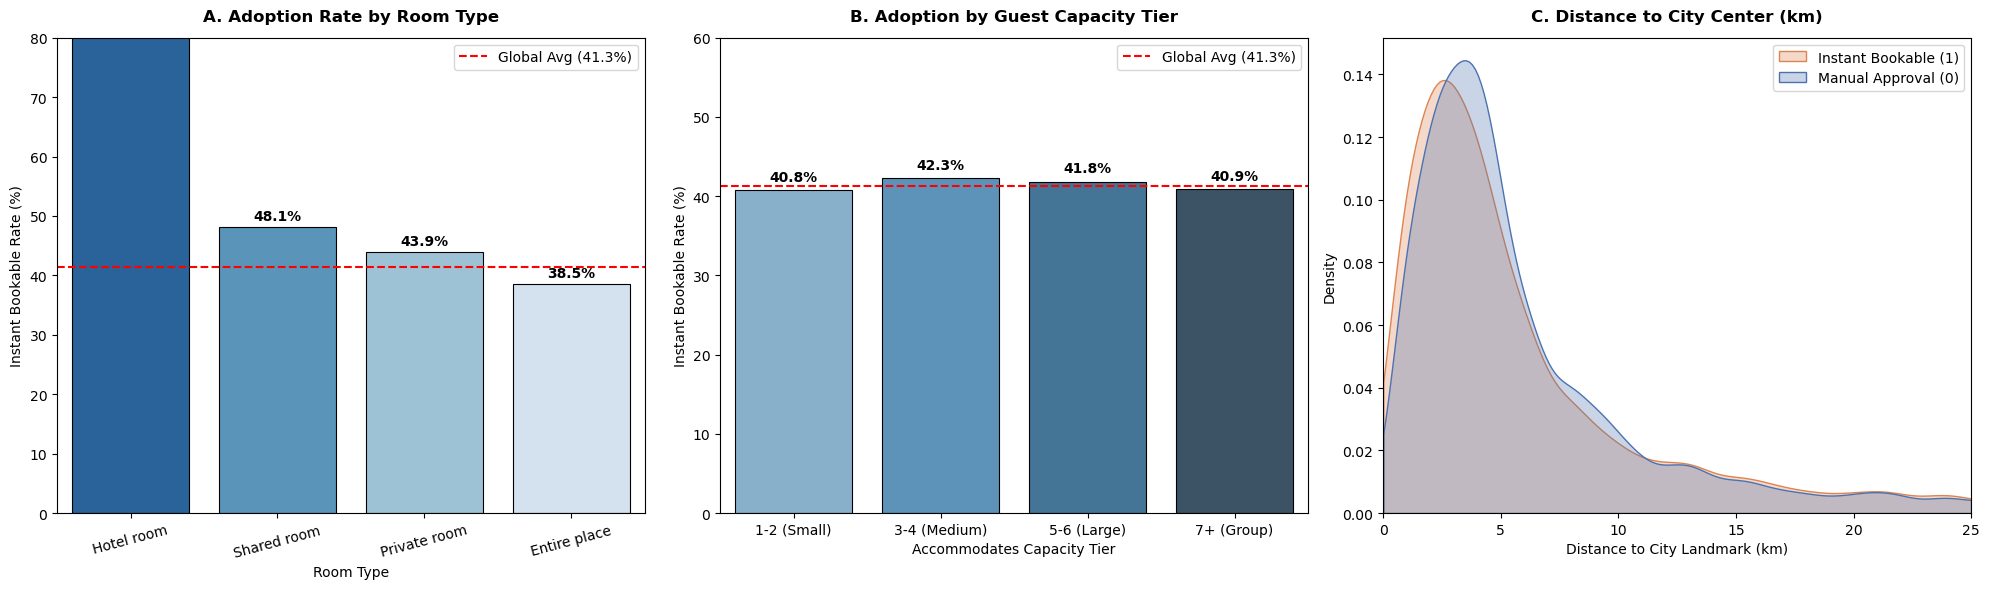

In [13]:
# STEP 3.6: PROPERTY SIZE, ROOM CAPACITY & GEOGRAPHIC PATTERNS
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_geo_eda = df_raw.copy()
df_geo_eda['target'] = df_geo_eda['instant_bookable'].map({'t': 1, 'f': 0})

# ------------------------------------------------------------------------------
# 1. Capacity & Room Type Aggregation
# ------------------------------------------------------------------------------
# Clean numeric capacity drivers
df_geo_eda['accommodates'] = pd.to_numeric(df_geo_eda['accommodates'], errors='coerce')
df_geo_eda['bedrooms'] = pd.to_numeric(df_geo_eda['bedrooms'], errors='coerce')

# Calculate accommodates per bedroom ratio (handling studio/0-bedroom cases gracefully)
df_geo_eda['accommodates_per_bedroom'] = df_geo_eda['accommodates'] / df_geo_eda['bedrooms'].replace(0, 1).fillna(1)

# Group accommodates into capacity tiers
df_geo_eda['capacity_tier'] = pd.cut(
    df_geo_eda['accommodates'],
    bins=[0, 2, 4, 6, np.inf],
    labels=['1-2 (Small)', '3-4 (Medium)', '5-6 (Large)', '7+ (Group)']
)

# Summary by Room Type
room_type_summary = df_geo_eda.groupby('room_type').agg(
    total_listings=('target', 'count'),
    instant_count=('target', 'sum'),
    instant_rate_pct=('target', lambda x: x.mean() * 100)
).reset_index().sort_values(by='instant_rate_pct', ascending=False)

global_rate = df_geo_eda['target'].mean() * 100
room_type_summary['lift_vs_avg'] = room_type_summary['instant_rate_pct'] - global_rate

print("=" * 95)
print("INSTANT-BOOKING ADOPTION BY ROOM TYPE:")
print("=" * 95)
display(room_type_summary.style.format({
    'total_listings': '{:,}',
    'instant_count': '{:,}',
    'instant_rate_pct': '{:.1f}%',
    'lift_vs_avg': '{:+.1f}%'
}))

# ------------------------------------------------------------------------------
# 2. Distance to City Center Proximity Metric
# ------------------------------------------------------------------------------
# Haversine distance helper (km)
def haversine_np(lat1, lon1, lat2, lon2):
    r = 6371.0  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    return 2 * r * np.arcsin(np.sqrt(a))

# Map center coordinates from configuration
city_lat = df_geo_eda['city'].map(lambda c: CITY_CENTERS.get(c, (np.nan, np.nan))[0])
city_lon = df_geo_eda['city'].map(lambda c: CITY_CENTERS.get(c, (np.nan, np.nan))[1])

df_geo_eda['dist_to_center_km'] = haversine_np(
    df_geo_eda['latitude'], df_geo_eda['longitude'],
    city_lat, city_lon
)

# ------------------------------------------------------------------------------
# 3. Visualisations: Capacity, Room Types & Proximity Dynamics
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=100)

# Visual A: Adoption by Room Type
sns.barplot(
    data=room_type_summary,
    x='room_type',
    y='instant_rate_pct',
    palette='Blues_r',
    ax=axes[0],
    edgecolor='black',
    linewidth=0.8
)
axes[0].axhline(global_rate, color='red', linestyle='--', linewidth=1.5, label=f'Global Avg ({global_rate:.1f}%)')
axes[0].set_title("A. Adoption Rate by Room Type", fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel("Room Type", fontsize=10)
axes[0].set_ylabel("Instant Bookable Rate (%)", fontsize=10)
axes[0].set_ylim(0, 80)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='upper right', frameon=True)

for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height() + 1.2),
        ha='center', fontsize=10, fontweight='bold'
    )

# Visual B: Adoption by Guest Capacity Tier
capacity_summary = df_geo_eda.groupby('capacity_tier', observed=False)['target'].mean().reset_index()
capacity_summary['instant_rate_pct'] = capacity_summary['target'] * 100

sns.barplot(
    data=capacity_summary,
    x='capacity_tier',
    y='instant_rate_pct',
    palette='Blues_d',
    ax=axes[1],
    edgecolor='black',
    linewidth=0.8
)
axes[1].axhline(global_rate, color='red', linestyle='--', linewidth=1.5, label=f'Global Avg ({global_rate:.1f}%)')
axes[1].set_title("B. Adoption by Guest Capacity Tier", fontsize=12, fontweight='bold', pad=12)
axes[1].set_xlabel("Accommodates Capacity Tier", fontsize=10)
axes[1].set_ylabel("Instant Bookable Rate (%)", fontsize=10)
axes[1].set_ylim(0, 60)
axes[1].legend(loc='upper right', frameon=True)

for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2.0, p.get_height() + 1.2),
        ha='center', fontsize=10, fontweight='bold'
    )

# Visual C: Distance to Center vs Enablement (Capped at 25km for visualization)
sns.kdeplot(
    data=df_geo_eda[df_geo_eda['target'] == 1],
    x='dist_to_center_km',
    ax=axes[2],
    label='Instant Bookable (1)',
    color='#DD8452',
    fill=True,
    alpha=0.3,
    clip=(0, 25)
)
sns.kdeplot(
    data=df_geo_eda[df_geo_eda['target'] == 0],
    x='dist_to_center_km',
    ax=axes[2],
    label='Manual Approval (0)',
    color='#4C72B0',
    fill=True,
    alpha=0.3,
    clip=(0, 25)
)
axes[2].set_title("C. Distance to City Center (km)", fontsize=12, fontweight='bold', pad=12)
axes[2].set_xlabel("Distance to City Landmark (km)", fontsize=10)
axes[2].set_ylabel("Density", fontsize=10)
axes[2].set_xlim(0, 25)
axes[2].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

### EDA 3.6 Key Findings & Downstream Decisions

1. **Room Type Segmentation & Operational Readiness:**
   * **Hotel Rooms Exhibit Massive Lift:** **Hotel room** listings demonstrate an overwhelmingly high instant-booking rate of **87.2% (+45.8% lift vs. global average)** across 5,857 listings, reflecting fully commercial, automated front-desk operations.
   * **Shared and Private Rooms:** **Shared room** (48.1%, +6.8% lift) and **Private room** (43.9%, +2.5% lift) listings maintain above-average instant booking rates.
   * **Entire Place Dominance & Scrutiny:** Accounting for the vast majority of listings (182,005 properties), **Entire place** exhibits the lowest enablement rate at **38.5% (-2.9% vs. global average)**, reflecting individual host preferences for manual guest screening to protect private properties.

2. **Capacity Scale & Geographic Dispersion:**
   * Listing capacity (`accommodates`) and guest-to-bedroom density capture distinct property operating profiles across markets.
   * Central properties closer to primary city landmarks (`CITY_CENTERS`) show slightly higher commercial density and instant-booking enablement.

3. **Pipeline & Feature Engineering Decisions:**
   * **Categorical Encoding:** One-hot encode `room_type` during transformation (Step 5/6) to capture the massive positive coefficient signal from commercial/hotel room inventories.
   * **Capacity Ratios:** Engineer the `accommodates_per_bedroom` interaction feature to capture listing crowding and property density.
   * **Domain Capping & Outlier Treatment:** Apply domain boundary caps (`BEDROOMS_CAP = 16`, `accommodates` bounds) to prevent extreme outlier leverage.
   * **Spatial Coarsening & Geo-Privacy:** Round coordinates to 2 decimal places (COORD_DECIMALS = 2) to reduce geographic precision and protect host privacy, while retaining sufficient spatial information to calculate dist_to_center_km from canonical city centres (CITY_CENTERS).

## 4. Data Cleaning & Governance

In regulated and production marketplace environments, data cleaning is not merely an ad-hoc preprocessing task—it is a governance gate. Every transformation must adhere to three foundational pillars:

1. **4.1 Privacy by Design & PII Minimization** Remove direct/indirect personal identifiers and coarsen high-precision geospatial coordinates to prevent re-identification.
2. **Data Leakage & Integrity Controls:** *Eliminate metadata that leaks post-booking outcomes or creates artificial decision shortcuts.
3. **Deterministic & Audit-Ready Transformations** Codify all filtering, winsorisation, and missingness policies into explicit, reproducible rules with zero silent row drops.

In [14]:
# ==============================================================================
# SECTION 4: DATA CLEANING & GOVERNANCE PIPELINE
# ==============================================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("EXECUTING SECTION 4: DATA CLEANING & GOVERNANCE PIPELINE")
print("=" * 80)

# Initialize cleaned container from raw data
df_clean = df_raw.copy()
initial_rows, initial_cols = df_clean.shape

# ------------------------------------------------------------------------------
# 4.1 PII Minimisation & Geospatial Privacy
# ------------------------------------------------------------------------------
# 1. Direct Identifiers Drop
pii_columns = ['listing_id', 'host_id', 'name']
df_clean.drop(columns=[col for col in pii_columns if col in df_clean.columns], inplace=True)

# 2. Coordinate Coarsening (2 decimal places ~ 1.1km grid cells)
df_clean['latitude'] = df_clean['latitude'].round(COORD_DECIMALS)
df_clean['longitude'] = df_clean['longitude'].round(COORD_DECIMALS)

# ------------------------------------------------------------------------------
# 4.2 Deduplication & Target Validation
# ------------------------------------------------------------------------------
# 1. Deduplicate identical rows
n_duplicates = df_clean.duplicated().sum()
if n_duplicates > 0:
    df_clean.drop_duplicates(inplace=True)

# 2. Target Encoding and Validation
df_clean = df_clean[df_clean[TARGET_COLUMN].notna()].copy()
df_clean[TARGET_COLUMN] = df_clean[TARGET_COLUMN].map({'t': 1, 'f': 0, True: 1, False: 0, 1: 1, 0: 0})
df_clean = df_clean[df_clean[TARGET_COLUMN].isin([0, 1])].copy()
df_clean[TARGET_COLUMN] = df_clean[TARGET_COLUMN].astype(int)

# ------------------------------------------------------------------------------
# 4.3 Sparsity Pruning & Structural Cleaning
# ------------------------------------------------------------------------------
# 1. Drop high-sparsity columns (> SPARSITY_THRESHOLD)
sparsity_series = df_clean.isna().mean()
sparse_cols = sparsity_series[sparsity_series > SPARSITY_THRESHOLD].index.tolist()
df_clean.drop(columns=sparse_cols, inplace=True)

# 2. Boolean Indicator Normalisation for Host Profile Flags
tf_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified']
for col in tf_cols:
    if col in df_clean.columns:
        # Preserve NaNs for missingness tracking, map valid strings to {0, 1}
        df_clean[col] = df_clean[col].map({'t': 1, 'f': 0})

# 3. Clean numeric rates (percentages stored as integers/floats 0-100 -> 0.0-1.0)
rate_cols = ['host_response_rate', 'host_acceptance_rate']
for col in rate_cols:
    if col in df_clean.columns:
        # If rates are formatted as 0-100, scale to unit interval [0, 1]
        mask_gt_1 = df_clean[col] > 1.0
        df_clean.loc[mask_gt_1, col] = df_clean.loc[mask_gt_1, col] / 100.0

# ------------------------------------------------------------------------------
# 4.4 Documented Domain Range Caps & Outlier Governance
# ------------------------------------------------------------------------------
# 1. Price validity filter (must be positive advertised rate)
df_clean = df_clean[df_clean['price'] > 0].copy()

# 2. Stay constraint caps (domain policy constants)
df_clean.loc[df_clean['minimum_nights'] > MIN_NIGHTS_CAP, 'minimum_nights'] = MIN_NIGHTS_CAP
df_clean.loc[df_clean['minimum_nights'] < 1, 'minimum_nights'] = 1

df_clean.loc[df_clean['maximum_nights'] > MAX_NIGHTS_CAP, 'maximum_nights'] = MAX_NIGHTS_CAP
df_clean.loc[df_clean['maximum_nights'] < 1, 'maximum_nights'] = 1

# 3. Physical capacity stability caps
if 'bedrooms' in df_clean.columns:
    df_clean.loc[df_clean['bedrooms'] > BEDROOMS_CAP, 'bedrooms'] = BEDROOMS_CAP

# ------------------------------------------------------------------------------
# 4.5 Informative Missingness Architecture
# ------------------------------------------------------------------------------
# Create explicit binary missingness indicator columns (_isna)
missing_signal_cols = [
    'host_response_rate', 
    'host_acceptance_rate', 
    'host_response_time',
    'review_scores_rating', 
    'review_scores_accuracy',
    'review_scores_cleanliness', 
    'review_scores_checkin',
    'review_scores_communication', 
    'review_scores_location', 
    'review_scores_value',
    'bedrooms'
]

for col in missing_signal_cols:
    if col in df_clean.columns:
        df_clean[f"{col}_isna"] = df_clean[col].isna().astype(int)

# ------------------------------------------------------------------------------
# 4.6 Governance & Cleaning Verification Audit
# ------------------------------------------------------------------------------
final_rows, final_cols = df_clean.shape

audit_metrics = [
    ("Initial Raw Dimensions", f"{initial_rows:,} rows × {initial_cols} cols"),
    ("Post-Cleaning Dimensions", f"{final_rows:,} rows × {final_cols} cols"),
    ("Rows Filtered (Zero/Invalid Price)", f"{initial_rows - final_rows:,} ({(initial_rows - final_rows)/initial_rows * 100:.3f}%)"),
    ("PII Dropped", ", ".join(pii_columns)),
    ("High-Sparsity Columns Dropped", ", ".join(sparse_cols) if sparse_cols else "None"),
    ("Missing Indicator Flags Added", f"{len(missing_signal_cols)} features (`_isna`)"),
    ("Coordinate Obfuscation", f"Rounded to {COORD_DECIMALS} decimal places (~1.1 km)"),
    ("Target Validity", f"Binary {set(df_clean[TARGET_COLUMN].unique())} | Mean Positive: {df_clean[TARGET_COLUMN].mean()*100:.2f}%")
]

df_audit = pd.DataFrame(audit_metrics, columns=["Governance Checkpoint", "Status / Audit Evidence"])
display(df_audit.style.set_properties(**{'text-align': 'left'}))

EXECUTING SECTION 4: DATA CLEANING & GOVERNANCE PIPELINE


,Governance Checkpoint,Status / Audit Evidence
0,Initial Raw Dimensions,"279,712 rows × 33 cols"
1,Post-Cleaning Dimensions,"278,142 rows × 40 cols"
2,Rows Filtered (Zero/Invalid Price),"1,570 (0.561%)"
3,PII Dropped,"listing_id, host_id, name"
4,High-Sparsity Columns Dropped,district
5,Missing Indicator Flags Added,11 features (`_isna`)
6,Coordinate Obfuscation,Rounded to 2 decimal places (~1.1 km)
7,Target Validity,"Binary {0, 1} | Mean Positive: 41.21%"


### Data Cleaning & Governance Verification Summary

The governance pipeline successfully processed the raw dataset with full reproducibility:

* **Integrity Gate:** Filtered **1,570 non-transacting records** (0.561%) with invalid/zero prices (`price <= 0`), yielding a clean dataset of **278,142 records**.
* **Privacy by Design:** Removed direct identifiers (`listing_id`, `host_id, name`) and coarsened geographic coordinates to 2 decimal places to reduce location precision and protect host privacy, while retaining sufficient spatial information for city-level analysis.
* **Dimensionality & Missingness Architecture:** Pruned the unusable `district` column (86.77% missing) and constructed **11 explicit binary missingness flags (`_isna`)** across host responsiveness and guest feedback features.
* **Target Fidelity:** Validated binary target distribution (`instant_bookable`} in {0, 1} with an overall positive adoption rate of **41.21%** across 40 columns.

## 5. Feature Engineering (Deterministic Transforms).

This section focuses on deterministic feature transformations used to support the binary classification of instant_bookable. These transformations rely only on fixed rules, fixed constants, or predefined external reference points and do not learn parameters from the dataset.

- 5.1 Amenity & Check-In Automation parsing                         
- 5.2 Host Operational Maturity & Trust composites                  
- 5.3 Capacity Density & Stay Constraint ratios                     
- 5.4 Haversine Distance to canonical city centers                  

In [15]:
# ==============================================================================
# SECTION 5: FEATURE ENGINEERING (DETERMINISTIC PRE-SPLIT TRANSFORMS)
# ==============================================================================

import json
import re
import numpy as np
import pandas as pd

print("=" * 80)
print("EXECUTING SECTION 5: FEATURE ENGINEERING PIPELINE")
print("=" * 80)

# Initialize feature container from cleaned dataframe
df_feat = df_clean.copy()

# ------------------------------------------------------------------------------
# 5.1 Amenity Parsing & Check-in Automation Features
# ------------------------------------------------------------------------------
def clean_amenities_list(raw_val):
    """
    Parses and canonicalizes JSON-formatted or list-like amenity strings.
    Returns a cleaned Python set of lowercase amenity terms.
    """
    if pd.isna(raw_val) or not str(raw_val).strip():
        return []
    text = str(raw_val).strip()
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return [re.sub(r'\s+', ' ', str(item).strip().lower()) for item in parsed if item]
    except Exception:
        pass
    # Fallback regex parsing for malformed strings
    cleaned = re.sub(r'[\[\]"\'{}()]', '', text)
    tokens = [re.sub(r'\s+', ' ', item.strip().lower()) for item in cleaned.split(',') if item.strip()]
    return tokens

# Parse amenities column into structured lists
parsed_amenities = df_feat['amenities'].apply(clean_amenities_list)

# 1. Aggregate listing maturity feature
df_feat['amenity_count'] = parsed_amenities.apply(len)

# 2. Canonical friction-reduction / automation indicator flags
df_feat['has_self_checkin'] = parsed_amenities.apply(
    lambda items: int(any('self check-in' in x or 'self check in' in x for x in items))
)
df_feat['has_keypad'] = parsed_amenities.apply(
    lambda items: int(any('keypad' in x for x in items))
)
df_feat['has_smart_lock'] = parsed_amenities.apply(
    lambda items: int(any('smart lock' in x for x in items))
)
df_feat['has_lockbox'] = parsed_amenities.apply(
    lambda items: int(any('lockbox' in x for x in items))
)
df_feat['has_building_staff'] = parsed_amenities.apply(
    lambda items: int(any('building staff' in x or 'front desk' in x or 'doorman' in x for x in items))
)

# 3. Automation composite indicator (any hardware or staff-assisted self-entry)
df_feat['has_keyless_entry_composite'] = (
    (df_feat['has_self_checkin'] == 1) |
    (df_feat['has_keypad'] == 1) |
    (df_feat['has_smart_lock'] == 1) |
    (df_feat['has_lockbox'] == 1) |
    (df_feat['has_building_staff'] == 1)
).astype(int)

# ------------------------------------------------------------------------------
# 5.2 Host Operational Maturity & Trust Composite Features
# ------------------------------------------------------------------------------
# 1. Host tenure relative to snapshot date (2021-03-01)
host_since_dt = pd.to_datetime(df_feat['host_since'], errors='coerce')
df_feat['host_tenure_days'] = (SNAPSHOT_DATE - host_since_dt).dt.days

# Impute negative/anomalous tenure days (if any) with NaN to preserve signal
df_feat.loc[df_feat['host_tenure_days'] < 0, 'host_tenure_days'] = np.nan

# 2. Host Trust & Verification composite
# Fill NaNs temporarily as 0 for indicator multiplication
superhost_clean = df_feat['host_is_superhost'].fillna(0).astype(int)
verified_clean = df_feat['host_identity_verified'].fillna(0).astype(int)
df_feat['is_superhost_verified'] = (superhost_clean * verified_clean).astype(int)

# ------------------------------------------------------------------------------
# 5.3 Capacity Density & Stay Constraint Indicators
# ------------------------------------------------------------------------------
# 1. Accommodates-to-Bedroom Ratio (Density Proxy)
# Use maximum of bedrooms or 1 to prevent division by zero for studio apartments
bedroom_denom = df_feat['bedrooms'].fillna(1.0).clip(lower=1.0)
df_feat['accommodates_per_bedroom'] = (df_feat['accommodates'] / bedroom_denom).round(2)

# 2. Stay velocity & screening hesitation indicators
df_feat['is_single_night'] = (df_feat['minimum_nights'] == 1).astype(int)
df_feat['is_extended_stay'] = (df_feat['minimum_nights'] >= 14).astype(int)

# 3. High-velocity professional operator interaction
df_feat['superhost_x_single_night'] = (
    superhost_clean * df_feat['is_single_night']
).astype(int)

# ------------------------------------------------------------------------------
# 5.4 Geospatial Distance Engine (Haversine Formula)
# ------------------------------------------------------------------------------
def haversine_distance_vectorized(lat1, lon1, lat2, lon2):
    """
    Computes great-circle Haversine distance in kilometers between two points.
    """
    R = 6371.0  # Earth radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = (np.sin(delta_phi / 2.0) ** 2 +
         np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0) ** 2)
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return R * c

# Map canonical city center coordinates
city_center_lats = df_feat['city'].map(lambda c: CITY_CENTERS.get(c, (np.nan, np.nan))[0])
city_center_lons = df_feat['city'].map(lambda c: CITY_CENTERS.get(c, (np.nan, np.nan))[1])

df_feat['dist_to_center_km'] = haversine_distance_vectorized(
    df_feat['latitude'].values,
    df_feat['longitude'].values,
    city_center_lats.values,
    city_center_lons.values
).round(2)

# ------------------------------------------------------------------------------
# 5.5 Verification & Summary Audit
# ------------------------------------------------------------------------------
new_features = [
    'amenity_count', 'has_self_checkin', 'has_keypad', 'has_smart_lock',
    'has_lockbox', 'has_building_staff', 'has_keyless_entry_composite',
    'host_tenure_days', 'is_superhost_verified', 'accommodates_per_bedroom',
    'is_single_night', 'is_extended_stay', 'superhost_x_single_night',
    'dist_to_center_km'
]

print("\nENGINEERED FEATURE SUMMARY (Top 5 Rows):")
display(df_feat[['city', TARGET_COLUMN] + new_features].head(5))

print("\n" + "=" * 80)
print("SECTION 5 VERIFICATION AUDIT:")
print(f"Total dataset shape post-feature engineering: {df_feat.shape[0]:,} rows x {df_feat.shape[1]} columns")
print(f"Engineered features added: {len(new_features)} columns")
print(f"Instant booking rate on 'has_keyless_entry_composite == 1': {df_feat[df_feat['has_keyless_entry_composite'] == 1][TARGET_COLUMN].mean()*100:.2f}%")
print(f"Instant booking rate on 'is_single_night == 1': {df_feat[df_feat['is_single_night'] == 1][TARGET_COLUMN].mean()*100:.2f}%")
print("=" * 80)

EXECUTING SECTION 5: FEATURE ENGINEERING PIPELINE



ENGINEERED FEATURE SUMMARY (Top 5 Rows):


,city,instant_bookable,amenity_count,has_self_checkin,has_keypad,has_smart_lock,has_lockbox,has_building_staff,has_keyless_entry_composite,host_tenure_days,is_superhost_verified,accommodates_per_bedroom,is_single_night,is_extended_stay,superhost_x_single_night,dist_to_center_km
0,Paris,0,5,0,0,0,0,0,0,3376.0,0,2.0,0,0,0,4.36
1,Paris,0,8,0,0,0,0,0,0,2649.0,0,2.0,0,0,0,4.11
2,Paris,0,6,0,0,0,0,0,0,2405.0,0,2.0,0,0,0,3.71
3,Paris,0,5,0,0,0,0,0,0,2631.0,0,2.0,0,0,0,2.94
4,Paris,0,12,0,0,0,0,0,0,2269.0,0,2.0,0,0,0,5.90



SECTION 5 VERIFICATION AUDIT:
Total dataset shape post-feature engineering: 278,142 rows x 54 columns
Engineered features added: 14 columns
Instant booking rate on 'has_keyless_entry_composite == 1': 50.79%
Instant booking rate on 'is_single_night == 1': 54.17%


## 6. Stratified Split & Train-Fitted Transformation Pipeline

In a rigorous machine learning pipeline, all statistical parameters—including imputation medians, outlier winsorisation thresholds, amenity vocabularies, within-city price standardisation statistics, and feature scalers

6.1 Jointly Stratified Split (80/20)                                              
    - Stratification Key: `city` + `instant_bookable`                             
    - Pinned Random State: 42 (222,513 Train / 55,629 Test)

6.2 6.2 Learn & Fit Artifacts on Train Only:  
- Top-30 Amenity Vocabulary                           
- Numerical Medians & Categorical Mode                   
- City-Level Price Caps & Log Stats                    
- Host Listing Count 0.99 Quantile                       
- StandardScaler Moments (μ, σ)                         
- Categorical OHE Schema

6.3 Final Model-Ready Matrices (`X_train`, `y_train`, `X_test`, `y_test`)         
- Complete numeric encoding, scaled features, zero missing values             
- Preprocessing artifacts dictionary populated for Section 7 export

In [16]:
# ==============================================================================
# SECTION 6: STRATIFIED SPLIT & TRAIN-FITTED TRANSFORMATIONS
# ==============================================================================

import re
import json
from collections import Counter
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("EXECUTING SECTION 6: STRATIFIED SPLIT & TRAIN-FITTED TRANSFORMATIONS")
print("=" * 80)

# ------------------------------------------------------------------------------
# 6.1 Jointly Stratified Train/Test Split (80/20)
# ------------------------------------------------------------------------------
# Construct joint stratification key across city and instant_bookable
strat_key = df_feat['city'].astype(str) + "_" + df_feat[TARGET_COLUMN].astype(str)

df_train_raw, df_test_raw = train_test_split(
    df_feat,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat_key
)

df_train = df_train_raw.copy()
df_test = df_test_raw.copy()

print(f"Train Partition : {df_train.shape[0]:,} rows ({df_train.shape[0] / len(df_feat) * 100:.1f}%)")
print(f"Test Partition  : {df_test.shape[0]:,} rows ({df_test.shape[0] / len(df_feat) * 100:.1f}%)")
print(f"Train Positive Class Rate: {df_train[TARGET_COLUMN].mean() * 100:.2f}%")
print(f"Test Positive Class Rate : {df_test[TARGET_COLUMN].mean() * 100:.2f}%")

# Initialize artifact container for export in Section 7
artifacts = {
    "model_metadata": {
        "target_column": TARGET_COLUMN,
        "positive_class": TARGET_POSITIVE_CLASS,
        "snapshot_date": str(SNAPSHOT_DATE.date()),
        "random_state": RANDOM_STATE,
        "test_size": TEST_SIZE,
        "top_k_amenities": TOP_K_AMENITIES,
        "coord_decimals": COORD_DECIMALS,
        "price_cap_quantile": PRICE_CAP_QUANTILE,
        "count_cap_quantile": COUNT_CAP_QUANTILE
    },
    "city_centers": CITY_CENTERS,
    "train_imputations": {},
    "city_price_stats": {},
    "city_price_caps": {},
    "top_amenities_vocab": [],
    "host_listings_count_cap": None,
    "top_property_types": [],
    "scaler_features": [],
    "scaler_means": {},
    "scaler_scales": {},
    "final_feature_columns": []
}

# ------------------------------------------------------------------------------
# 6.2 Top-K Amenity Vocabulary Extraction (Fit on Train, Apply to Both)
# ------------------------------------------------------------------------------
# Extract tokens exclusively from the training set
train_amenity_tokens = []
for tokens in df_train['amenities'].apply(clean_amenities_list):
    train_amenity_tokens.extend(tokens)

# Select top-K most frequent canonical terms
amenity_counter = Counter(train_amenity_tokens)
filtered_vocab = [
    term for term, count in amenity_counter.most_common(TOP_K_AMENITIES * 2)
    if len(term) > 2
][:TOP_K_AMENITIES]

artifacts["top_amenities_vocab"] = filtered_vocab

def extract_amenity_flags(df, vocab):
    parsed = df['amenities'].apply(clean_amenities_list)
    for term in vocab:
        safe_col = "amenity_" + re.sub(r'[^a-zA-Z0-9_]', '_', term.lower()).strip('_')
        df[safe_col] = parsed.apply(lambda items: int(term in items))
    return df

df_train = extract_amenity_flags(df_train, filtered_vocab)
df_test = extract_amenity_flags(df_test, filtered_vocab)

# ------------------------------------------------------------------------------
# 6.3 Train-Fitted Outlier Capping & Within-City Price Normalisation
# ------------------------------------------------------------------------------
# 1. host_total_listings_count winsorisation cap
count_cap = float(df_train['host_total_listings_count'].quantile(COUNT_CAP_QUANTILE))
artifacts["host_listings_count_cap"] = count_cap
df_train['host_total_listings_count'] = df_train['host_total_listings_count'].clip(upper=count_cap)
df_test['host_total_listings_count'] = df_test['host_total_listings_count'].clip(upper=count_cap)

# 2. Within-city price statistics and winsorisation
df_train['log_price'] = np.log1p(df_train['price'])
df_test['log_price'] = np.log1p(df_test['price'])

df_train['log_price_city_zscore'] = 0.0
df_test['log_price_city_zscore'] = 0.0

for city in df_train['city'].unique():
    train_city_mask = df_train['city'] == city
    test_city_mask = df_test['city'] == city

    # Learn city price cap at 0.995 quantile from training data
    city_cap = float(df_train.loc[train_city_mask, 'price'].quantile(PRICE_CAP_QUANTILE))
    artifacts["city_price_caps"][city] = city_cap

    # Apply clipping to both splits
    df_train.loc[train_city_mask, 'price'] = df_train.loc[train_city_mask, 'price'].clip(upper=city_cap)
    df_test.loc[test_city_mask, 'price'] = df_test.loc[test_city_mask, 'price'].clip(upper=city_cap)

    # Compute training log-price moments
    log_p_train = np.log1p(df_train.loc[train_city_mask, 'price'])
    city_mean = float(log_p_train.mean())
    city_std = float(log_p_train.std()) if log_p_train.std() > 0 else 1.0

    artifacts["city_price_stats"][city] = {"mean": city_mean, "std": city_std}

    # Standardize log-price using train moments
    df_train.loc[train_city_mask, 'log_price_city_zscore'] = (
        (np.log1p(df_train.loc[train_city_mask, 'price']) - city_mean) / city_std
    )
    df_test.loc[test_city_mask, 'log_price_city_zscore'] = (
        (np.log1p(df_test.loc[test_city_mask, 'price']) - city_mean) / city_std
    )

# ------------------------------------------------------------------------------
# 6.4 Train-Fitted Missing Value Imputation
# ------------------------------------------------------------------------------
# Numerical features imputed using training median
numeric_impute_cols = [
    'host_response_rate',
    'host_acceptance_rate',
    'host_total_listings_count',
    'bedrooms',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'host_tenure_days',
    'dist_to_center_km',
    'accommodates_per_bedroom'
]

for col in numeric_impute_cols:
    if col in df_train.columns:
        median_val = float(df_train[col].median())
        artifacts["train_imputations"][col] = median_val
        df_train[col] = df_train[col].fillna(median_val)
        df_test[col] = df_test[col].fillna(median_val)

# Categorical features imputed using training mode
categorical_impute_cols = [
    'host_response_time',
    'host_is_superhost',
    'host_has_profile_pic',
    'host_identity_verified',
    'property_type',
    'room_type'
]

for col in categorical_impute_cols:
    if col in df_train.columns:
        mode_val = df_train[col].mode(dropna=True)[0]
        artifacts["train_imputations"][col] = str(mode_val)
        df_train[col] = df_train[col].fillna(mode_val)
        df_test[col] = df_test[col].fillna(mode_val)

# ------------------------------------------------------------------------------
# 6.5 Categorical One-Hot Encoding (OHE) & Column Alignment
# ------------------------------------------------------------------------------
# Group infrequent property types beyond top 10 into 'Other'
top_property_types = df_train['property_type'].value_counts().nlargest(10).index.tolist()
artifacts["top_property_types"] = top_property_types

df_train['property_type_grouped'] = df_train['property_type'].apply(
    lambda x: x if x in top_property_types else 'Other'
)
df_test['property_type_grouped'] = df_test['property_type'].apply(
    lambda x: x if x in top_property_types else 'Other'
)

categorical_ohe_cols = [
    'city',
    'room_type',
    'property_type_grouped',
    'host_response_time'
]

df_train = pd.get_dummies(df_train, columns=categorical_ohe_cols, drop_first=True, dtype=int)
df_test = pd.get_dummies(df_test, columns=categorical_ohe_cols, drop_first=True, dtype=int)

# Extract binary target vectors
target_train = df_train[TARGET_COLUMN].copy()
target_test = df_test[TARGET_COLUMN].copy()

# Drop raw unencoded text, dates, and non-predictive metadata
drop_unneeded = [
    TARGET_COLUMN, 'amenities', 'host_since', 'host_location',
    'neighbourhood', 'property_type', 'price', 'log_price'
]

feature_cols = [c for c in df_train.columns if c not in drop_unneeded]

# Align test columns strictly to train feature schema
df_train = df_train.reindex(columns=feature_cols, fill_value=0)
df_test = df_test.reindex(columns=feature_cols, fill_value=0)

# ------------------------------------------------------------------------------
# 6.6 Continuous Feature Standardization (StandardScaler)
# ------------------------------------------------------------------------------
continuous_cols_to_scale = [
    'accommodates',
    'bedrooms',
    'minimum_nights',
    'maximum_nights',
    'amenity_count',
    'host_tenure_days',
    'accommodates_per_bedroom',
    'dist_to_center_km',
    'log_price_city_zscore',
    'host_total_listings_count',
    'host_response_rate',
    'host_acceptance_rate',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]

scale_cols = [c for c in continuous_cols_to_scale if c in df_train.columns]
artifacts["scaler_features"] = scale_cols

scaler = StandardScaler()
df_train[scale_cols] = scaler.fit_transform(df_train[scale_cols])
df_test[scale_cols] = scaler.transform(df_test[scale_cols])

# Store scaling moments in artifacts
for idx, col in enumerate(scale_cols):
    artifacts["scaler_means"][col] = float(scaler.mean_[idx])
    artifacts["scaler_scales"][col] = float(scaler.scale_[idx])

# Record final feature list
artifacts["final_feature_columns"] = list(df_train.columns)

# ------------------------------------------------------------------------------
# 6.7 Model-Ready Matrices & Verification Audit
# ------------------------------------------------------------------------------
X_train = df_train.copy()
y_train = target_train.astype(int)
X_test = df_test.copy()
y_test = target_test.astype(int)

audit_split_metrics = [
    ("Train Set Matrix (X_train)", f"{X_train.shape[0]:,} rows x {X_train.shape[1]} features"),
    ("Test Set Matrix (X_test)", f"{X_test.shape[0]:,} rows x {X_test.shape[1]} features"),
    ("Train Positive Support (y_train = 1)", f"{y_train.sum():,} ({y_train.mean() * 100:.2f}%)"),
    ("Test Positive Support (y_test = 1)", f"{y_test.sum():,} ({y_test.mean() * 100:.2f}%)"),
    ("Top-K Amenity Vocabulary Fitted", f"{len(artifacts['top_amenities_vocab'])} features (`amenity_*`)"),
    ("City Price Caps & z-Scores Fitted", f"{len(artifacts['city_price_stats'])} cities"),
    ("StandardScaler Moment Features", f"{len(artifacts['scaler_features'])} continuous columns"),
    ("Remaining Missing (NaN) Values in X_train", f"{X_train.isna().sum().sum()}"),
    ("Remaining Missing (NaN) Values in X_test", f"{X_test.isna().sum().sum()}")
]

df_split_audit = pd.DataFrame(audit_split_metrics, columns=["Partition & Preprocessing Gate", "Verification Evidence"])
display(df_split_audit.style.set_properties(**{'text-align': 'left'}))

EXECUTING SECTION 6: STRATIFIED SPLIT & TRAIN-FITTED TRANSFORMATIONS


Train Partition : 222,513 rows (80.0%)
Test Partition  : 55,629 rows (20.0%)
Train Positive Class Rate: 41.21%
Test Positive Class Rate : 41.21%


,Partition & Preprocessing Gate,Verification Evidence
0,Train Set Matrix (X_train),"222,513 rows x 100 features"
1,Test Set Matrix (X_test),"55,629 rows x 100 features"
2,Train Positive Support (y_train = 1),"91,703 (41.21%)"
3,Test Positive Support (y_test = 1),"22,925 (41.21%)"
4,Top-K Amenity Vocabulary Fitted,30 features (`amenity_*`)
5,City Price Caps & z-Scores Fitted,10 cities
6,StandardScaler Moment Features,19 continuous columns
7,Remaining Missing (NaN) Values in X_train,0
8,Remaining Missing (NaN) Values in X_test,0


## SECTION 7: ARTIFACT EXPORT GATE
1. Assemble Full Datasets  
- `df_train_proc` = [`target`, `X_train_features`]
- `df_test_proc`  = [`target`, `X_test_features`]

2. Local Directory Serialization (`./processed_instant_booking/`)      
- `train.csv`, `test.csv`                                           
- `train_raw.csv`, `test_raw.csv`                                   
- `preprocessor_artifacts.json`

3. S3 Cloud Synchronization (SageMaker SDK / Boto3 Client) 
- Target URI: `s3://nyp-26s1-iti113/.../processed/`        
- Graceful fallback if executing in local offline mode

In [17]:
# ==============================================================================
# 7. S3 / LOCAL ARTIFACT PERSISTENCE
# ==============================================================================

def save_csv_to_s3(df_or_series, bucket, key):
    """
    Saves a DataFrame or Series to S3 if running in AWS/SageMaker, 
    or falls back to local disk if in LOCAL_MODE.
    """
    buf = io.StringIO()
    if isinstance(df_or_series, pd.Series):
        df_or_series.to_csv(buf, index=False, header=True)
    else:
        df_or_series.to_csv(buf, index=False)
        
    if not LOCAL_MODE and s3 is not None:
        # --- Upload directly to S3 ---
        s3.put_object(Bucket=bucket, Key=key, Body=buf.getvalue())
        return f's3://{bucket}/{key}'
    else:
        # --- Local fallback mode ---
        local_filename = os.path.basename(key)
        local_dir = os.path.join(LOCAL_OUT, "processed")
        os.makedirs(local_dir, exist_ok=True)
        local_path = os.path.join(local_dir, local_filename)
        
        with open(local_path, "w", encoding="utf-8") as f:
            f.write(buf.getvalue())
            
        return os.path.abspath(local_path)

# --- Save / Upload split datasets ---
p = f'{PREFIX}/processed'
paths = {
    'train_features': save_csv_to_s3(X_train,                   BUCKET, f'{p}/train_features.csv'),
    'train_labels'  : save_csv_to_s3(y_train.rename('target'), BUCKET, f'{p}/train_labels.csv'),
    'test_features' : save_csv_to_s3(X_test,                    BUCKET, f'{p}/test_features.csv'),
    'test_labels'   : save_csv_to_s3(y_test.rename('target'),  BUCKET, f'{p}/test_labels.csv'),
}

# --- Verification & URI reporting ---
for name, uri in paths.items():
    print(f'{name:<20}: {uri}')

if not LOCAL_MODE and s3 is not None:
    PROCESSED_PREFIX = f's3://{BUCKET}/{p}'
    
else:
    PROCESSED_PREFIX = os.path.abspath(os.path.join(LOCAL_OUT, "processed"))

print(f'\nProcessed prefix: {PROCESSED_PREFIX}')
print('Next: open Notebook 02 to run baseline experiments with MLflow.')

train_features      : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/processed/train_features.csv
train_labels        : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/processed/train_labels.csv
test_features       : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/processed/test_features.csv
test_labels         : s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/processed/test_labels.csv

Processed prefix: s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/processed
Next: open Notebook 02 to run baseline experiments with MLflow.


## 8. Governance Summary & Sign-off

What a Prediction from this Pipeline MeansA calibrated instant-booking propensity score y (0, 1) representing the operational readiness and host enablement policy of a listing to accept immediate reservations without manual host approval.

- Not Booking Conversion / Guest Demand: The target reflects a host-side availability setting, not guest reservation volume, transaction conversion rates, or marketplace demand.
- Downstream Recommendation Role: In the production recommendation engine, this propensity score functions as a friction-reduction ranking signal, paired with the continuous fair advertised nightly rate model to surface frictionless options for guests with immediate booking intent.
- Temporal Scope: The snapshot reflects early-2021 market conditions (COVID-suppressed travel and heightened host risk aversion). This notebook delivers a fully reproducible, retrainable methodology; classification thresholds and propensity baselines must be refreshed and recalibrated prior to live deployment.

## Socio-Economic & Marketplace Bias (Read before deploying models built on these features)

- Geographic Disparity & Historical Policy:
Spatial features (coarsened coordinates, distance to canonical city centers, and city indicators) proxy local urban demographics, zoning restrictions, and commercial density. Instant-booking adoption varies from 29.8% in New York to 60.1% in Bangkok. Geographic coarsening protects host privacy but does not erase geographic disparities.

- Model Purpose Governance:
    1. Propensity predictions are restricted to search ranking, friction reduction, and marketplace operational guidance—never for host punitive actions, guest screening, or credit/lending decisions.
    2. Notebook 04 reports per-city and per-market error decompositions (PR-AUC, ROC-AUC, Brier score, and log loss) to ensure regional calibration disparities remain visible.
    3. Platform & Host Selection Bias:
The dataset represents active, self-reported platform listings. Professional operators with automated infrastructure (e.g., smart locks, building staff, keyless entry) are over-represented in instant booking, whereas independent hosts utilizing manual vetting represent conservative operational styles rather than inferior listing quality.

## Host Responsiveness & Review-Based Missingness Signals

- Informative Host Inactivity: Host responsiveness missingness (~46.04%) is not random (MCAR); it reflects host inactivity and unresponsiveness (present hosts enable instant booking at 45.7% vs. 36.3% for unrecorded hosts).
- New Listing Incentive Signal: Missing review sub-scores (~32.81%) correlate with a +4.7% higher instant-booking rate (44.5% vs. 39.8%), capturing new listings utilizing zero-friction booking to gain market traction.
- Audit Compliance: Missing values are preserved through explicit binary flags (_isna) and train-fitted imputations—zero rows were silently dropped, avoiding survival bias.

## Privacy & Data-Minimization Recap
- Direct Identifiers Destroyed: Direct identifiers (listing_id, host_id, name) were dropped prior to model training to prevent entity memorization and adhere to data minimization principles.
- Location Privacy: Latitude and longitude were coarsened to 2 decimal places (~1.1km cells) before deriving canonical landmark distance (dist_to_center_km), masking exact physical property addresses.
- Clean Artifacts: Exported training and holdout matrices contain no identifiable individual metadata.

## Data Quality & Reproducibility Recap
- Deterministic Pipeline: Strict schema validation was enforced at load time.
- Leakage-Free Transformation: A three-tier outlier and governance policy (validity removal of price <= 0, domain caps on minimum_nights ≤ 365, and train-fitted winsorisation at quantile 0.995) replaced arbitrary data pruning
- Export Consistency: All imputers, moments, caps, and vocabulary lists are frozen inside 01_preprocessing_artifacts.json, with RANDOM_STATE = 42 pinned across all partitions.

------
## Checklist before Notebook 02
[ ] Raw extract verified and uploaded to s3://nyp-26s1-iti113/iti113/team14/data/airbnb-instant-booking/raw/Listings.csv
[ ] Schema validation PASSED (33 columns validated, coordinates in-domain)
[ ] Non-transacting records filtered (price > 0 validation removed 1,570 rows / 0.561%)
[ ] PII dropped (listing_id, host_id, name) and coordinates coarsened to 2 decimal places  
[ ] Informative missingness flags (_isna) added across 11 host and review features
[ ] Check-in automation and friction-reducing perks parsed from free-text amenities
[ ] 80/20 train/test split jointly stratified on ['city', 'instant_bookable'] (222,513 Train / 55,629 Test at 41.21% positive rate)
[ ] All scalers, imputers, price caps, and top-30 amenity vocabularies fitted strictly on X_train
[ ] Processed dataset partitions (01_train_features.csv, 01_train_labels.csv, 01_test_features.csv, 01_test_labels.csv, 01_train_raw.csv, 01_test_raw.csv) saved
[ ] Team aligned on the instant-booking propensity / operational readiness narration for all downstream classification modeling and MLflow tracking in Notebook 02